# Canine Lymph Node Metastasis Prediction in Oral Cancers

C Pinard & A Lagree

# 1. Load Packages

### Package Loading (Bulk)

In [1]:
%pip install --upgrade pip setuptools

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install versioneer
!pip install git+https://github.com/AIM-Harvard/pyradiomics.git
#!pip install pyradiomics
!pip install pydicom
!pip install ipywidgets jupyterlab_widgets
!pip install ipympl

  Cloning https://github.com/AIM-Harvard/pyradiomics.git to C:\Users\sshuser\AppData\Local\Temp\pip-req-build-injqi_rr
  Resolved https://github.com/AIM-Harvard/pyradiomics.git to commit 8ed579383b44806651c463d5e691f3b2b57522ab
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/AIM-Harvard/pyradiomics.git 'C:\Users\sshuser\AppData\Local\Temp\pip-req-build-injqi_rr'


In [3]:
# CT Radiomics Pipeline for Canine Oral Tumor Lymph Node Metastasis Prediction
# Complete pipeline from image preprocessing to ML model evaluation


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Image processing
import SimpleITK as sitk
from skimage import measure, morphology, filters
from scipy import ndimage
import cv2

# Radiomics
import pyradiomics as radiomics
import logging

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.pipeline import Pipeline

# Gradient Boosting
import xgboost as xgb

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Statistical analysis
from scipy import stats
import scipy.stats as stats

# Set random seed for reproducibility
np.random.seed(42)

# Configure radiomics logging
logging.getLogger('radiomics').setLevel(logging.ERROR)


    # RO

### DICOM Loader

Found 50 CT cases:
  1. 256069_CT
  2. 405570_CT
  3. 602120_CT
  4. 619781_CT
  5. 621897_CT
  6. 622732_CT
  7. 622814_CT
  8. 624950_CT
  9. 627020_CT
  10. 628681_CT
  11. 630434_CT
  12. 630633_CT
  13. 635020_CT
  14. 635209_CT
  15. 635960_CT
  16. 636235_CT
  17. 637045_CT
  18. 637263_CT
  19. 640555_CT
  20. 641688_CT
  21. 644873_CT
  22. 645028_CT
  23. 645592_CT
  24. 646187_CT
  25. 647623_CT
  26. 648945_CT
  27. 649071_CT
  28. 649234_CT
  29. 650425_CT
  30. 654045_CT
  31. 656637_CT
  32. 656758_CT
  33. 656825_CT
  34. 657393_CT
  35. 658095_CT
  36. 660291_CT
  37. 660359_CT
  38. 660394_CT
  39. 660496_CT
  40. 660818_CT
  41. 661840_CT
  42. 662134_CT
  43. 662249_CT
  44. 665502_CT
  45. 665806_CT
  46. 665870_CT
  47. 667223_CT
  48. 669720_CT
  49. 670239_CT
  50. 670489_CT

Using default case: 256069_CT
Found 1 series in C:\Users\sshuser\Documents\SLN Radiomics Projects\ct_working_data\ct_images\256069_CT


IntSlider(value=24, description='Slice:', max=47)

Interactive preview ready. Move the slider to scroll through slices.


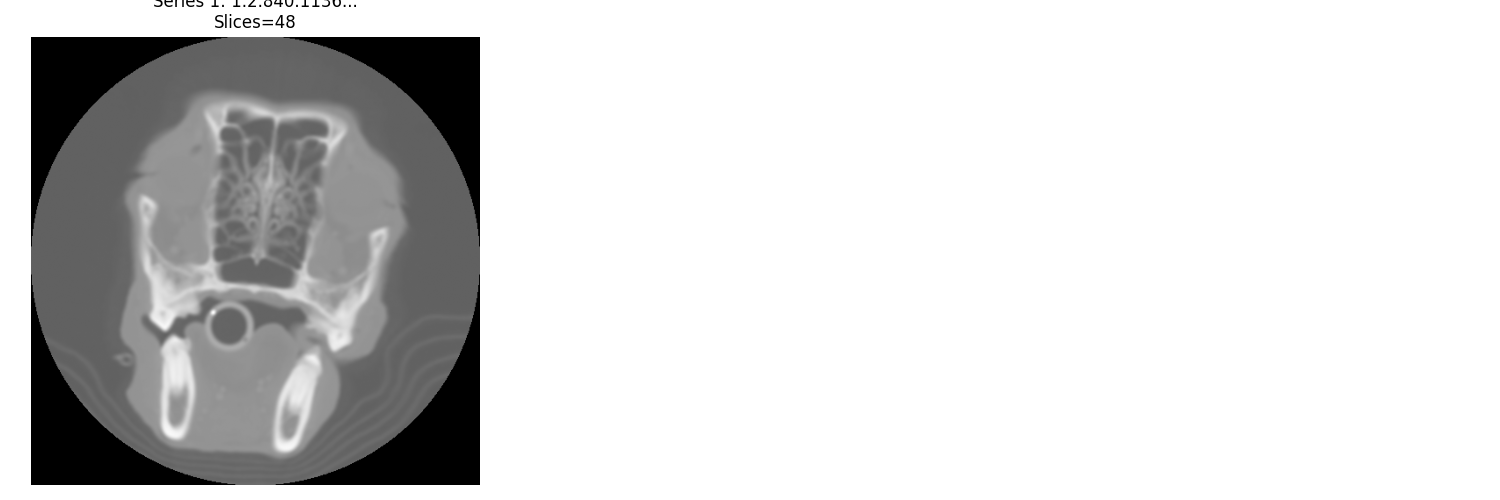

In [4]:
from pathlib import Path
import pydicom
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from typing import Dict, List

# Base directory containing all CT cases
base_ct_dir = Path(r"C:\Users\sshuser\Documents\SLN Radiomics Projects\ct_working_data\ct_images")
assert base_ct_dir.is_dir(), f"Not a directory: {base_ct_dir}"

# Get all available CT case directories
ct_cases = [d for d in base_ct_dir.iterdir() if d.is_dir() and d.name.endswith('_CT')]
ct_case_names = [d.name for d in ct_cases]

print(f"Found {len(ct_cases)} CT cases:")
for i, case_name in enumerate(ct_case_names):
    print(f"  {i+1}. {case_name}")

# Default to first case if available
dicom_dir = ct_cases[0] if ct_cases else None
if dicom_dir:
    print(f"\nUsing default case: {dicom_dir.name}")
else:
    raise FileNotFoundError(f"No CT cases found in {base_ct_dir}")


def collect_series_filelists(folder: Path) -> Dict[str, List[Path]]:
	"""Scan a folder and group DICOM files by SeriesInstanceUID.

	Returns a dict: {series_uid: [list of dicom file Paths]}.
	Skips non-DICOM files gracefully. Uses stop_before_pixels to avoid heavy I/O.
	"""
	series_to_files: Dict[str, List[Path]] = {}
	for p in folder.iterdir():
		if not p.is_file():
			continue
		try:
			ds = pydicom.dcmread(str(p), stop_before_pixels=True, force=True)
			series_uid = getattr(ds, "SeriesInstanceUID", None)
			if series_uid is None:
				continue
			series_to_files.setdefault(series_uid, []).append(p)
		except Exception:
			# Not a readable DICOM; skip
			continue
	return series_to_files


def sort_series_files(files: List[Path]) -> List[Path]:
	"""Sort slices using InstanceNumber, ImagePositionPatient, or SliceLocation."""
	def sort_key(p: Path):
		try:
			ds = pydicom.dcmread(str(p), stop_before_pixels=True, force=True)
			# Prefer InstanceNumber if present
			if hasattr(ds, "InstanceNumber"):
				return (0, int(ds.InstanceNumber))
			# Next: use ImagePositionPatient Z
			if hasattr(ds, "ImagePositionPatient") and len(ds.ImagePositionPatient) == 3:
				return (1, float(ds.ImagePositionPatient[2]))
			# Fallback: SliceLocation
			if hasattr(ds, "SliceLocation"):
				return (2, float(ds.SliceLocation))
		except Exception:
			pass
		# Final fallback: filename
		return (9, p.name)

	return sorted(files, key=sort_key)


def load_series_volume(sorted_files: List[Path]) -> sitk.Image:
	"""Load a 3D volume from a sorted list of DICOM files using SimpleITK."""
	reader = sitk.ImageSeriesReader()
	reader.SetFileNames([str(p) for p in sorted_files])
	img = reader.Execute()
	return img


# Collect and preview all series in the folder
series_map = collect_series_filelists(dicom_dir)
if not series_map:
	raise FileNotFoundError(f"No readable DICOM series found in {dicom_dir}")

print(f"Found {len(series_map)} series in {dicom_dir}")

# Preload all series volumes to support fast interactive scrolling
series_volumes = []  # list of (series_uid, volume_np [z,y,x])
max_slices = 0
for series_uid, file_list in series_map.items():
	sorted_files = sort_series_files(file_list)
	vol = load_series_volume(sorted_files)
	vol_np = sitk.GetArrayFromImage(vol)
	series_volumes.append((series_uid, vol_np))
	max_slices = max(max_slices, int(vol_np.shape[0]))

fig_cols = 3
fig_rows = int(np.ceil(len(series_volumes) / fig_cols))
from IPython import get_ipython
_ip = get_ipython()
use_widget_backend = False
try:
	import ipympl  # noqa: F401
	_ip.run_line_magic('matplotlib', 'ipympl')
	use_widget_backend = True
except Exception:
	_ip.run_line_magic('matplotlib', 'inline')
	use_widget_backend = False

fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(5*fig_cols, 5*fig_rows))
axes = np.atleast_1d(axes).ravel()

# Ensure ipywidgets is available
try:
	import ipywidgets as widgets
	from IPython.display import display
except Exception:
	import sys as _sys
	print("Installing ipywidgets...")
	!{_sys.executable} -m pip install -q ipywidgets
	import ipywidgets as widgets
	from IPython.display import display

# Slider controls which slice index to show (applied to all series)
slice_slider = widgets.IntSlider(value=max_slices // 2 if max_slices > 0 else 0,
	min=0, max=max(0, max_slices - 1), step=1,
	description='Slice:', continuous_update=True)

# Initialize images on axes
img_artists = []
for idx, (series_uid, vol_np) in enumerate(series_volumes):
	z = min(slice_slider.value, int(vol_np.shape[0]) - 1)
	slice2d = vol_np[z]
	m = float(np.nanmin(slice2d))
	M = float(np.nanmax(slice2d))
	disp = (slice2d - m) / (M - m + 1e-6)
	ax = axes[idx]
	artist = ax.imshow(disp, cmap='gray')
	ax.set_title(f"Series {idx+1}: {series_uid[:12]}...\nSlices={vol_np.shape[0]}")
	ax.axis('off')
	img_artists.append(artist)

# Hide any unused axes
for j in range(len(series_volumes), len(axes)):
	axes[j].axis('off')

plt.tight_layout()

def _on_slice_change(change):
	if change['name'] != 'value':
		return
	z = int(change['new'])
	for idx, (series_uid, vol_np) in enumerate(series_volumes):
		if idx >= len(img_artists):
			break
		zz = min(z, int(vol_np.shape[0]) - 1)
		slice2d = vol_np[zz]
		m = float(np.nanmin(slice2d))
		M = float(np.nanmax(slice2d))
		disp = (slice2d - m) / (M - m + 1e-6)
		img_artists[idx].set_data(disp)
	fig.canvas.draw_idle()

slice_slider.observe(_on_slice_change)

if use_widget_backend:
	display(slice_slider)
	# Widget backend updates in-place
else:
	from IPython.display import display, clear_output
	out = widgets.Output()
	def _on_slice_change_inline(change):
		if change['name'] != 'value':
			return
		with out:
			clear_output(wait=True)
			# Redraw figure with updated data
			for idx, (series_uid, vol_np) in enumerate(series_volumes):
				zz = min(int(change['new']), int(vol_np.shape[0]) - 1)
				slice2d = vol_np[zz]
				m = float(np.nanmin(slice2d))
				M = float(np.nanmax(slice2d))
				disp = (slice2d - m) / (M - m + 1e-6)
				img_artists[idx].set_data(disp)
			fig.canvas.draw()
			plt.show()
	# Wire the inline handler
	slice_slider.observe(_on_slice_change_inline)
	display(widgets.VBox([slice_slider, out]))

print("Interactive preview ready. Move the slider to scroll through slices.")


### Interactive DICOM Viewer

In [5]:
# Interactive CT Case Selection with Dropdown
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

# Create dropdown widget for case selection
case_dropdown = widgets.Dropdown(
    options=ct_case_names,
    value=ct_case_names[0] if ct_case_names else None,
    description='Select CT Case:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='300px')
)

# Create output widget for displaying case information
case_info_output = widgets.Output()

# Create output widget for displaying the DICOM viewer
viewer_output = widgets.Output()

def update_case_selection(change):
    """Update the DICOM viewer when a new case is selected"""
    if change['new'] is None:
        return
    
    # Find the selected case directory
    selected_case_name = change['new']
    selected_case_dir = None
    for case_dir in ct_cases:
        if case_dir.name == selected_case_name:
            selected_case_dir = case_dir
            break
    
    if selected_case_dir is None:
        with case_info_output:
            clear_output()
            print(f"Error: Case directory not found for {selected_case_name}")
        return
    
    # Update global dicom_dir variable
    global dicom_dir
    dicom_dir = selected_case_dir
    
    # Display case information
    with case_info_output:
        clear_output()
        print(f"Selected Case: {selected_case_name}")
        print(f"Directory: {selected_case_dir}")
        
        # Get case statistics
        try:
            series_map = collect_series_filelists(selected_case_dir)
            print(f"Number of series: {len(series_map)}")
            
            for i, (series_uid, file_list) in enumerate(series_map.items()):
                print(f"  Series {i+1}: {len(file_list)} files")
                
                # Get some DICOM metadata from first file
                if file_list:
                    try:
                        ds = pydicom.dcmread(str(file_list[0]), stop_before_pixels=True, force=True)
                        if hasattr(ds, 'SliceThickness'):
                            print(f"    Slice thickness: {ds.SliceThickness} mm")
                        if hasattr(ds, 'PixelSpacing'):
                            print(f"    Pixel spacing: {ds.PixelSpacing}")
                        if hasattr(ds, 'Rows') and hasattr(ds, 'Columns'):
                            print(f"    Image dimensions: {ds.Rows} x {ds.Columns}")
                    except Exception as e:
                        print(f"    Could not read metadata: {e}")
        except Exception as e:
            print(f"Error analyzing case: {e}")
    
    # Update the DICOM viewer
    with viewer_output:
        clear_output()
        try:
            # Re-run the DICOM viewer code for the selected case
            run_dicom_viewer_for_case(selected_case_dir)
        except Exception as e:
            print(f"Error loading DICOM viewer: {e}")

def run_dicom_viewer_for_case(case_dir):
    """Run the DICOM viewer for a specific case"""
    # Collect and preview all series in the folder
    series_map = collect_series_filelists(case_dir)
    if not series_map:
        print(f"No readable DICOM series found in {case_dir}")
        return

    print(f"Found {len(series_map)} series in {case_dir}")

    # Preload all series volumes to support fast interactive scrolling
    series_volumes = []  # list of (series_uid, volume_np [z,y,x])
    max_slices = 0
    for series_uid, file_list in series_map.items():
        sorted_files = sort_series_files(file_list)
        vol = load_series_volume(sorted_files)
        vol_np = sitk.GetArrayFromImage(vol)
        series_volumes.append((series_uid, vol_np))
        max_slices = max(max_slices, int(vol_np.shape[0]))

    fig_cols = min(3, len(series_volumes))
    fig_rows = int(np.ceil(len(series_volumes) / fig_cols))
    
    fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(5*fig_cols, 5*fig_rows))
    if fig_rows == 1 and fig_cols == 1:
        axes = [axes]
    elif fig_rows == 1:
        axes = axes
    else:
        axes = axes.ravel()

    # Slider controls which slice index to show (applied to all series)
    slice_slider = widgets.IntSlider(
        value=max_slices // 2 if max_slices > 0 else 0,
        min=0, max=max(0, max_slices - 1), step=1,
        description='Slice:', continuous_update=True
    )

    # Initialize images on axes
    img_artists = []
    for idx, (series_uid, vol_np) in enumerate(series_volumes):
        z = min(slice_slider.value, int(vol_np.shape[0]) - 1)
        slice2d = vol_np[z]
        m = float(np.nanmin(slice2d))
        M = float(np.nanmax(slice2d))
        disp = (slice2d - m) / (M - m + 1e-6)
        ax = axes[idx]
        artist = ax.imshow(disp, cmap='gray')
        ax.set_title(f"Series {idx+1}: {series_uid[:12]}...\nSlices={vol_np.shape[0]}")
        ax.axis('off')
        img_artists.append(artist)

    # Hide any unused axes
    for j in range(len(series_volumes), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()

    def _on_slice_change(change):
        if change['name'] != 'value':
            return
        z = int(change['new'])
        for idx, (series_uid, vol_np) in enumerate(series_volumes):
            if idx >= len(img_artists):
                break
            zz = min(z, int(vol_np.shape[0]) - 1)
            slice2d = vol_np[zz]
            m = float(np.nanmin(slice2d))
            M = float(np.nanmax(slice2d))
            disp = (slice2d - m) / (M - m + 1e-6)
            img_artists[idx].set_data(disp)
        fig.canvas.draw_idle()

    slice_slider.observe(_on_slice_change)
    display(slice_slider)
    plt.show()

# Wire the dropdown to the update function
case_dropdown.observe(update_case_selection, names='value')

# Display the interface
print("CT Case Selection Interface:")
display(case_dropdown)
display(case_info_output)
display(viewer_output)

# Initialize with the first case
if ct_case_names:
    case_dropdown.value = ct_case_names[0]


CT Case Selection Interface:


Dropdown(description='Select CT Case:', layout=Layout(width='300px'), options=('256069_CT', '405570_CT', '6021…

Output()

Output()

### CT + Mask Loading

In [6]:
# Interactive CT + Mask Viewer - Cleaned & Condensed
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
import SimpleITK as sitk
from pathlib import Path

# Setup paths and discover cases
ct_images_dir = Path(r"C:\Users\sshuser\Documents\SLN Radiomics Projects\ct_working_data\ct_images")
ct_mask_dir = Path(r"C:\Users\sshuser\Documents\SLN Radiomics Projects\ct_working_data\ct_mask")

# Discover available cases
available_cases = []
for ct_dir in ct_images_dir.iterdir():
    if ct_dir.is_dir() and ct_dir.name.endswith('_CT'):
        patient_id = ct_dir.name.replace('_CT', '')
        mask_file = ct_mask_dir / f"{patient_id}.nii"
        if mask_file.exists():
            available_cases.append({
                'case_name': ct_dir.name,
                'patient_id': patient_id,
                'ct_dir': ct_dir,
                'mask_file': mask_file
            })

print(f"Found {len(available_cases)} cases with CT images and masks")

# Create widgets
case_dropdown = widgets.Dropdown(
    options=[case['case_name'] for case in available_cases],
    value=available_cases[0]['case_name'] if available_cases else None,
    description='Case:', layout=widgets.Layout(width='200px')
)

mask_visibility = widgets.Checkbox(value=True, description='Show Mask')
mask_alpha = widgets.FloatSlider(value=0.4, min=0.1, max=1.0, step=0.1, description='Opacity')
mask_colormap = widgets.Dropdown(
    options=['autumn', 'hot', 'cool', 'spring', 'viridis', 'plasma'],
    value='autumn', description='Color'
)
mask_label_selector = widgets.Dropdown(options=[], description='Lymph Node:', layout=widgets.Layout(width='150px'))

# Output widgets
case_info_output = widgets.Output()
viewer_output = widgets.Output()

# Global state
current_data = {'ct_array': None, 'mask_array': None, 'labels': None, 'fig': None, 'ax': None, 'slider': None}

def load_volumes(ct_dir, mask_file):
    """Load and resample CT and mask volumes"""
    try:
        # Load CT
        reader = sitk.ImageSeriesReader()
        series_ids = reader.GetGDCMSeriesIDs(str(ct_dir))
        if not series_ids:
            return None, None, None
        
        dicom_names = reader.GetGDCMSeriesFileNames(str(ct_dir), series_ids[0])
        reader.SetFileNames(dicom_names)
        ct_image = reader.Execute()
        
        # Load mask
        mask_image = sitk.ReadImage(str(mask_file))
        mask_array = sitk.GetArrayFromImage(mask_image)
        unique_labels = np.unique(mask_array)[np.unique(mask_array) > 0]
        
        # Resample mask to match CT if needed
        ct_size, mask_size = ct_image.GetSize(), mask_image.GetSize()
        ct_spacing, mask_spacing = ct_image.GetSpacing(), mask_image.GetSpacing()
        
        if (ct_size != mask_size or 
            any(abs(c - m) > 0.1 for c, m in zip(ct_spacing, mask_spacing))):
            resampler = sitk.ResampleImageFilter()
            resampler.SetReferenceImage(ct_image)
            resampler.SetInterpolator(sitk.sitkNearestNeighbor)
            resampler.SetDefaultPixelValue(0)
            mask_image = resampler.Execute(mask_image)
        
        return ct_image, mask_image, unique_labels
        
    except Exception as e:
        print(f"Error loading volumes: {e}")
        return None, None, None

def update_case_info(selected_case):
    """Update case information display"""
    with case_info_output:
        clear_output()
        ct_image, mask_image, labels = load_volumes(selected_case['ct_dir'], selected_case['mask_file'])
        
        if ct_image and mask_image is not None:
            print(f"Case: {selected_case['case_name']}")
            print(f"CT: {ct_image.GetSize()}, {ct_image.GetSpacing()}")
            print(f"Mask: {mask_image.GetSize()}, Labels: {labels}")
        else:
            print("Error loading case data")

def display_slice(z, show_mask=True, alpha=0.4, colormap='autumn'):
    """Display a specific slice"""
    if current_data['ct_array'] is None or current_data['ax'] is None:
        return
    
    z = max(0, min(z, current_data['ct_array'].shape[0] - 1))
    
    # Display CT
    ct_slice = current_data['ct_array'][z]
    ct_normalized = (ct_slice - np.min(ct_slice)) / (np.max(ct_slice) - np.min(ct_slice) + 1e-6)
    
    current_data['ax'].clear()
    current_data['ax'].imshow(ct_normalized, cmap='gray', origin='lower')
    
    # Display mask if enabled
    if show_mask and current_data['mask_array'] is not None:
        mask_slice = current_data['mask_array'][z]
        selected_label = mask_label_selector.value
        
        if selected_label == 'All':
            mask_overlay = np.ma.masked_where(mask_slice == 0, mask_slice)
        else:
            label_num = int(selected_label.split()[-1])
            specific_mask = (mask_slice == label_num).astype(np.uint8)
            mask_overlay = np.ma.masked_where(specific_mask == 0, specific_mask)
        
        if np.sum(mask_overlay.mask == False) > 0:  # If there are visible pixels
            current_data['ax'].imshow(mask_overlay, cmap=colormap, alpha=alpha, origin='lower')
    
    current_data['ax'].set_title(f"{current_data.get('case_name', '')} - Slice {z+1}/{current_data['ct_array'].shape[0]}")
    current_data['ax'].axis('off')
    current_data['fig'].canvas.draw_idle()

def update_viewer(selected_case):
    """Update the viewer with new case"""
    global current_data
    
    with viewer_output:
        clear_output()
        
        ct_image, mask_image, labels = load_volumes(selected_case['ct_dir'], selected_case['mask_file'])
        
        if not ct_image or not mask_image:
            print("Error loading volumes")
            return
        
        # Store data globally
        current_data['ct_array'] = sitk.GetArrayFromImage(ct_image)
        current_data['mask_array'] = sitk.GetArrayFromImage(mask_image).astype(np.uint8)
        current_data['labels'] = labels
        current_data['case_name'] = selected_case['case_name']
        
        # Update label selector
        label_options = ['All'] + [f'Lymph Node {label}' for label in labels]
        mask_label_selector.options = label_options
        mask_label_selector.value = 'All'
        
        # Create figure
        current_data['fig'], current_data['ax'] = plt.subplots(1, 1, figsize=(8, 8))
        
        # Create slider
        z_middle = current_data['ct_array'].shape[0] // 2
        current_data['slider'] = widgets.IntSlider(
            value=z_middle, min=0, max=current_data['ct_array'].shape[0] - 1,
            description='Slice:', continuous_update=True, layout=widgets.Layout(width='300px')
        )
        
        def on_slice_change(change):
            display_slice(change['new'], mask_visibility.value, mask_alpha.value, mask_colormap.value)
        
        current_data['slider'].observe(on_slice_change, names='value')
        
        # Display controls and initial slice
        controls = widgets.VBox([
            widgets.HBox([current_data['slider']]),
            widgets.HBox([mask_visibility, mask_alpha, mask_colormap, mask_label_selector])
        ])
        
        display(controls)
        display_slice(z_middle, mask_visibility.value, mask_alpha.value, mask_colormap.value)
        plt.show()

# Event handlers
def on_case_change(change):
    if change['new']:
        selected_case = next(case for case in available_cases if case['case_name'] == change['new'])
        update_case_info(selected_case)
        update_viewer(selected_case)

def on_control_change(change):
    if current_data['slider'] is not None:
        display_slice(current_data['slider'].value, mask_visibility.value, mask_alpha.value, mask_colormap.value)

# Wire up events
case_dropdown.observe(on_case_change, names='value')
mask_visibility.observe(on_control_change, names='value')
mask_alpha.observe(on_control_change, names='value')
mask_colormap.observe(on_control_change, names='value')
mask_label_selector.observe(on_control_change, names='value')

# Display interface
print("CT + Mask Interactive Viewer")
display(case_dropdown)
display(case_info_output)
display(viewer_output)

# Initialize
if available_cases:
    case_dropdown.value = available_cases[0]['case_name']


Found 50 cases with CT images and masks
CT + Mask Interactive Viewer


Dropdown(description='Case:', layout=Layout(width='200px'), options=('256069_CT', '405570_CT', '602120_CT', '6…

Output()

Output()

In [7]:
!pip install openpyxl

# 1. Data Setup

In [8]:
# ============================================================================
# BLOCK A: Data Setup — Load Excel and Build Per-LN Records
# ============================================================================
# Each patient contributes up to 4 observations (one per lymph node site).
# Mask label  2 -> L Mandibular       (LN_LM)
# Mask label  6 -> R Mandibular       (LN_RM)
# Mask label  5 -> L Retropharyngeal  (LN_LR)
# Mask label  4 -> R Retropharyngeal  (LN_RR)
# ============================================================================

import pandas as pd
import numpy as np
from pathlib import Path

EXCEL_PATH  = Path(r"C:\Users\sshuser\Documents\SLN Radiomics Projects\SLN AI Master Patient Data List.xlsx")
CT_IMG_DIR  = Path(r"C:\Users\sshuser\Documents\SLN Radiomics Projects\ct_working_data\ct_images")
CT_MASK_DIR = Path(r"C:\Users\sshuser\Documents\SLN Radiomics Projects\ct_working_data\ct_mask")

# Mask label <-> LN site name <-> outcome column in Excel
LN_MAP = [
    {"label": 2, "site": "L_Mandibular",      "col": "LN_LM"},
    {"label": 6, "site": "R_Mandibular",       "col": "LN_RM"},
    {"label": 5, "site": "L_Retropharyngeal",  "col": "LN_LR"},
    {"label": 4, "site": "R_Retropharyngeal",  "col": "LN_RR"},
]

# -- Load Excel ---------------------------------------------------------------
raw = pd.read_excel(EXCEL_PATH, header=1)   # row 1 is the true header row
raw.columns = raw.iloc[0]                    # row 0 carries the actual column names
raw = raw.iloc[1:].reset_index(drop=True)
raw = raw.rename(columns={raw.columns[0]: "patient_id"})

keep_cols = ["patient_id"] + [m["col"] for m in LN_MAP]
clinical  = raw[keep_cols].copy()
clinical["patient_id"] = clinical["patient_id"].astype(str).str.strip()

for m in LN_MAP:
    clinical[m["col"]] = pd.to_numeric(clinical[m["col"]], errors="coerce")

clinical = clinical.dropna(subset=[m["col"] for m in LN_MAP]).reset_index(drop=True)

# -- Deduplicate: flag and keep first occurrence of any repeated patient ID --
dupes = clinical[clinical.duplicated(subset="patient_id", keep=False)]
if not dupes.empty:
    print(f"Duplicate patient IDs found (keeping first occurrence):")
    print(dupes[["patient_id"] + [m["col"] for m in LN_MAP]].to_string(index=False))

clinical = clinical.drop_duplicates(subset="patient_id", keep="first").reset_index(drop=True)
print(f"Unique patients with complete LN outcome data: {len(clinical)}")

# -- Find patients that have both a CT dir and mask file ----------------------
records = []
missing = []

for _, row in clinical.iterrows():
    pid      = str(row["patient_id"])
    ct_dir   = CT_IMG_DIR  / f"{pid}_CT"
    mask_nii = CT_MASK_DIR / f"{pid}.nii"

    if not ct_dir.exists():
        missing.append((pid, "no CT dir"))
        continue
    if not mask_nii.exists():
        missing.append((pid, "no mask file"))
        continue

    for m in LN_MAP:
        records.append({
            "patient_id": pid,
            "ln_site":    m["site"],
            "ln_label":   m["label"],
            "metastatic": int(row[m["col"]]),
            "ct_dir":     str(ct_dir),
            "mask_file":  str(mask_nii),
        })

if missing:
    print(f"\nSkipped {len(missing)} patients (missing files):")
    for pid, reason in missing:
        print(f"  {pid}: {reason}")

per_ln_df = pd.DataFrame(records)
n_patients = per_ln_df["patient_id"].nunique()
print(f"\nTotal LN observations:  {len(per_ln_df)}  ({n_patients} patients × 4 sites)")
print(f"Patients represented:   {n_patients}")
print("\nClass balance per site:")
print(per_ln_df.groupby(["ln_site", "metastatic"]).size().unstack(fill_value=0))
print("\nOverall metastatic prevalence:", per_ln_df["metastatic"].mean().round(3))
per_ln_df.head(8)

Duplicate patient IDs found (keeping first occurrence):
patient_id  LN_LM  LN_RM  LN_LR  LN_RR
    256069    0.0    0.0    0.0    0.0
    256069    0.0    0.0    0.0    0.0
Unique patients with complete LN outcome data: 51

Skipped 1 patients (missing files):
  674915: no CT dir

Total LN observations:  200  (50 patients × 4 sites)
Patients represented:   50

Class balance per site:
metastatic          0  1
ln_site                 
L_Mandibular       43  7
L_Retropharyngeal  49  1
R_Mandibular       41  9
R_Retropharyngeal  48  2

Overall metastatic prevalence: 0.095


,patient_id,ln_site,ln_label,metastatic,ct_dir,mask_file
0,650425,L_Mandibular,2,0,C:\Users\sshuser\Documents\SLN Radiomics Proje...,C:\Users\sshuser\Documents\SLN Radiomics Proje...
1,650425,R_Mandibular,6,0,C:\Users\sshuser\Documents\SLN Radiomics Proje...,C:\Users\sshuser\Documents\SLN Radiomics Proje...
2,650425,L_Retropharyngeal,5,0,C:\Users\sshuser\Documents\SLN Radiomics Proje...,C:\Users\sshuser\Documents\SLN Radiomics Proje...
3,650425,R_Retropharyngeal,4,0,C:\Users\sshuser\Documents\SLN Radiomics Proje...,C:\Users\sshuser\Documents\SLN Radiomics Proje...
4,654045,L_Mandibular,2,0,C:\Users\sshuser\Documents\SLN Radiomics Proje...,C:\Users\sshuser\Documents\SLN Radiomics Proje...
5,654045,R_Mandibular,6,0,C:\Users\sshuser\Documents\SLN Radiomics Proje...,C:\Users\sshuser\Documents\SLN Radiomics Proje...
6,654045,L_Retropharyngeal,5,0,C:\Users\sshuser\Documents\SLN Radiomics Proje...,C:\Users\sshuser\Documents\SLN Radiomics Proje...
7,654045,R_Retropharyngeal,4,0,C:\Users\sshuser\Documents\SLN Radiomics Proje...,C:\Users\sshuser\Documents\SLN Radiomics Proje...


# 2. Data Loading and Organization

In [9]:
# -- GPU / CUDA check ---------------------------------------------------------
# Probes driver + toolkit + XGBoost CUDA support, and exports module-level
# flags (USE_GPU, XGB_DEVICE, XGB_TREE_METHOD) that downstream cells consume.
print("=" * 60)
print("GPU / CUDA check")
print("=" * 60)

import subprocess
import numpy as np

USE_GPU         = False
XGB_DEVICE      = "cpu"
XGB_TREE_METHOD = "hist"
GPU_NAME        = None

# 1) NVIDIA driver visible?
try:
    r = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total,driver_version",
         "--format=csv,noheader"],
        capture_output=True, text=True, timeout=10)
    if r.returncode == 0 and r.stdout.strip():
        GPU_NAME = r.stdout.strip()
        print(f"GPU detected     : {GPU_NAME}")
    else:
        print("GPU detected     : none (nvidia-smi returned no devices)")
except FileNotFoundError:
    print("GPU detected     : nvidia-smi not on PATH")
except Exception as e:
    print(f"GPU detected     : probe failed ({e})")

# 2) CUDA toolkit (nvcc) — optional but informative
try:
    r = subprocess.run(["nvcc", "--version"], capture_output=True, text=True, timeout=10)
    if r.returncode == 0:
        ver = [l for l in r.stdout.splitlines() if "release" in l.lower()]
        print(f"CUDA toolkit     : {ver[0].strip() if ver else r.stdout.strip()}")
    else:
        print("CUDA toolkit     : nvcc not found (OK if xgboost wheel bundles CUDA)")
except Exception:
    print("CUDA toolkit     : nvcc not found (OK if xgboost wheel bundles CUDA)")

# 3) PyTorch CUDA (only reported if torch happens to be installed)
try:
    import torch
    if torch.cuda.is_available():
        print(f"PyTorch CUDA     : available | device={torch.cuda.get_device_name(0)}")
    else:
        print("PyTorch CUDA     : torch installed but CUDA not available")
except ImportError:
    pass

# 4) XGBoost CUDA probe — the decisive check for Block F
try:
    import xgboost as xgb
    _X = np.random.rand(16, 4).astype("float32")
    _y = np.array([0, 1] * 8, dtype="int32")
    xgb.XGBClassifier(
        n_estimators=2, max_depth=2,
        device="cuda", tree_method="hist",
        verbosity=0,
    ).fit(_X, _y)
    USE_GPU, XGB_DEVICE, XGB_TREE_METHOD = True, "cuda", "hist"
    print(f"XGBoost CUDA     : OK    (device=cuda, tree_method=hist)")
except Exception as e:
    USE_GPU, XGB_DEVICE, XGB_TREE_METHOD = False, "cpu", "hist"
    msg = str(e).splitlines()[0][:100]
    print(f"XGBoost CUDA     : unavailable -- falling back to CPU  ({msg})")

# 5) PyRadiomics: note that no maintained GPU build exists on PyPI.
# Block C parallelizes the per-LN extraction across CPU threads instead --
# that is the realistic acceleration path for radiomic feature extraction.
print("PyRadiomics       : CPU-only (no pyradiomics-cuda package on PyPI); "
      "Block C runs in parallel threads for speedup")

print("-" * 60)
print(f"USE_GPU         = {USE_GPU}")
print(f"XGB_DEVICE      = {XGB_DEVICE!r}")
print(f"XGB_TREE_METHOD = {XGB_TREE_METHOD!r}")
print("=" * 60)

# NOTE: Block F runs ~49 LOOCV folds on tiny train sets (~190 rows x ~10 feats).
# XGBoost GPU has per-call overhead that can make it SLOWER than CPU for data
# this small. If you want to force-disable GPU for Block F even when CUDA is
# detected, set USE_GPU = False in a cell before running Block F.


GPU / CUDA check
GPU detected     : NVIDIA GeForce RTX 4080, 16376 MiB, 595.79
CUDA toolkit     : Cuda compilation tools, release 12.9, V12.9.41
PyTorch CUDA     : available | device=NVIDIA GeForce RTX 4080
XGBoost CUDA     : OK    (device=cuda, tree_method=hist)
PyRadiomics       : CPU-only (no pyradiomics-cuda package on PyPI); Block C runs in parallel threads for speedup
------------------------------------------------------------
USE_GPU         = True
XGB_DEVICE      = 'cuda'
XGB_TREE_METHOD = 'hist'


In [10]:
# ============================================================================
# BLOCK B: Preprocessing — Load CT + Multi-Label Mask, Resample to 1 mm^3
# ============================================================================

import SimpleITK as sitk
import numpy as np
from pathlib import Path
import subprocess

TARGET_SPACING = [1.0, 1.0, 1.0]  # mm isotropic


def load_dicom_ct(ct_dir):
    """
    Load a DICOM series; picks the largest series capped at 600 slices.
    The cap avoids accidentally selecting thin-overlap reconstructions or
    multi-phase acquisitions (e.g. patient 628681 had a 1040-slice series).
    """
    reader = sitk.ImageSeriesReader()
    uids   = reader.GetGDCMSeriesIDs(str(ct_dir))
    if not uids:
        raise FileNotFoundError(f"No DICOM series in {ct_dir}")

    candidates = sorted(
        [(len(reader.GetGDCMSeriesFileNames(str(ct_dir), u)), u) for u in uids],
        reverse=True
    )
    best_uid = next(
        (u for n, u in candidates if n <= 600),
        candidates[0][1]  # fallback to absolute largest if all > 600
    )
    reader.SetFileNames(reader.GetGDCMSeriesFileNames(str(ct_dir), best_uid))
    return reader.Execute()


def resample_to_spacing(image, new_spacing, interpolator):
    """Resample image to a target voxel spacing."""
    orig_spacing = image.GetSpacing()
    orig_size    = image.GetSize()
    new_size = [
        int(round(orig_size[i] * orig_spacing[i] / new_spacing[i]))
        for i in range(3)
    ]
    r = sitk.ResampleImageFilter()
    r.SetOutputSpacing(new_spacing)
    r.SetSize(new_size)
    r.SetOutputDirection(image.GetDirection())
    r.SetOutputOrigin(image.GetOrigin())
    r.SetTransform(sitk.Transform())
    r.SetInterpolator(interpolator)
    r.SetDefaultPixelValue(-1024 if interpolator == sitk.sitkBSpline else 0)
    return r.Execute(image)


def resample_mask_to_reference(mask, reference_image):
    """Resample mask into the exact physical space of reference_image."""
    r = sitk.ResampleImageFilter()
    r.SetReferenceImage(reference_image)
    r.SetInterpolator(sitk.sitkNearestNeighbor)
    r.SetDefaultPixelValue(0)
    return r.Execute(mask)


def preprocess_patient(ct_dir, mask_file, patient_id,
                        target_spacing=None, verbose=True):
    """
    Load CT and mask, resample both to target spacing.
    Mask is resampled using the resampled CT as reference, guaranteeing
    identical size, spacing, origin and direction — no geometry mismatch.
    """
    if target_spacing is None:
        target_spacing = TARGET_SPACING
    try:
        ct_orig = load_dicom_ct(Path(ct_dir))
        mask    = sitk.ReadImage(str(mask_file))
        mask    = sitk.Cast(mask, sitk.sitkUInt8)

        ct_rs   = resample_to_spacing(ct_orig, target_spacing, sitk.sitkBSpline)
        mask_rs = resample_mask_to_reference(mask, ct_rs)

        if verbose:
            present    = np.unique(sitk.GetArrayFromImage(mask_rs))
            present    = present[present > 0].tolist()
            size_match = ct_rs.GetSize() == mask_rs.GetSize()
            status     = "OK" if (present and size_match) else "WARNING"
            print(f"  [{status}] {patient_id}: CT {ct_rs.GetSize()} | "
                  f"mask {mask_rs.GetSize()} | labels: {present}")

        return ct_rs, mask_rs

    except Exception as e:
        print(f"  ERROR {patient_id}: {e}")
        return None, None


# -- Pre-process all unique patients ------------------------------------------
# Memory-safe: each (CT, mask) pair is written to disk as .nii.gz immediately
# after resampling, and `preprocessed` holds only (ct_path, mask_path) tuples.
# This prevents OOM crashes when holding 49 resampled CTs in RAM, and makes
# re-runs cheap (we skip patients whose cache already exists).

import gc
try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **kw: x

PREPROC_CACHE_DIR = Path("preproc_cache")
PREPROC_CACHE_DIR.mkdir(exist_ok=True)

def _cache_paths(pid):
    return (PREPROC_CACHE_DIR / f"{pid}_ct.nii.gz",
            PREPROC_CACHE_DIR / f"{pid}_mask.nii.gz")

unique_patients = (
    per_ln_df[["patient_id", "ct_dir", "mask_file"]]
    .drop_duplicates("patient_id")
    .reset_index(drop=True)
)
print(f"Pre-processing {len(unique_patients)} patients "
      f"to {TARGET_SPACING} mm isotropic ...")
print(f"Cache directory: {PREPROC_CACHE_DIR.resolve()}\n")

preprocessed = {}          # pid -> (ct_path, mask_path)
failed       = []
n_cached_hit = 0

for _, row in tqdm(unique_patients.iterrows(),
                   total=len(unique_patients), desc="Preprocessing"):
    pid = row["patient_id"]
    ct_path, mask_path = _cache_paths(pid)

    # Cache hit: skip re-preprocessing
    if ct_path.exists() and mask_path.exists():
        preprocessed[pid] = (ct_path, mask_path)
        n_cached_hit += 1
        continue

    ct, mask = preprocess_patient(row["ct_dir"], row["mask_file"], pid)
    if ct is None or mask is None:
        failed.append(pid)
        continue

    # Write compressed NIfTI (SimpleITK picks compression from the extension)
    sitk.WriteImage(ct,   str(ct_path),   useCompression=True)
    sitk.WriteImage(mask, str(mask_path), useCompression=True)
    preprocessed[pid] = (ct_path, mask_path)

    # Release the big arrays before the next patient
    del ct, mask
    gc.collect()

print(f"\nSuccessfully preprocessed: "
      f"{len(preprocessed)}/{len(unique_patients)} patients "
      f"({n_cached_hit} from cache, "
      f"{len(preprocessed) - n_cached_hit} freshly resampled)")
if failed:
    print(f"Failed: {failed}")

# Sanity: confirm files are readable and small enough
_total_mb = sum((p[0].stat().st_size + p[1].stat().st_size) / 1e6
                for p in preprocessed.values())
print(f"Cache size on disk: {_total_mb:.0f} MB "
      f"(avg {_total_mb/max(len(preprocessed),1):.1f} MB/patient)")


Pre-processing 50 patients to [1.0, 1.0, 1.0] mm isotropic ...
Cache directory: C:\Users\sshuser\Documents\SLN Radiomics Projects\preproc_cache



Preprocessing:   0%|          | 0/50 [00:00<?, ?it/s]

  [OK] 405570: CT (186, 186, 402) | mask (186, 186, 402) | labels: [2, 4, 5, 6]
  [OK] 660818: CT (103, 103, 111) | mask (103, 103, 111) | labels: [2, 4, 5, 6]
  [OK] 649234: CT (169, 169, 206) | mask (169, 169, 206) | labels: [2, 4, 5, 6]
  [OK] 635020: CT (173, 173, 254) | mask (173, 173, 254) | labels: [2, 4, 5, 6]
  [OK] 656758: CT (259, 259, 362) | mask (259, 259, 362) | labels: [2, 4, 5, 6]

Successfully preprocessed: 50/50 patients (45 from cache, 5 freshly resampled)
Cache size on disk: 922 MB (avg 18.4 MB/patient)


# 4. Feature Extraction with PyRadiomics

In [11]:
# ============================================================================
# BLOCK C: Feature Extraction -- PyRadiomics Per Lymph Node Label
# ============================================================================
# PyRadiomics is CPU-only (no maintained GPU/CUDA build on PyPI). We
# parallelize per-LN extraction across CPU threads with joblib: PyRadiomics'
# C extensions release the GIL during computation, so threading gives a real
# wall-clock speedup without the Windows multiprocessing pickle overhead.
# Each worker instantiates its own extractor to avoid shared-state races.

from radiomics import featureextractor
import SimpleITK as sitk
import numpy as np
import pandas as pd
import os
from joblib import Parallel, delayed

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **kw: x

N_EXTRACT_WORKERS = max(1, (os.cpu_count() or 2) - 1)
print(f"PyRadiomics extraction will use {N_EXTRACT_WORKERS} CPU threads "
      f"(GPU path not available for PyRadiomics)")

# -- PyRadiomics extractor setup ----------------------------------------------
PYRAD_PARAMS = {
    "binWidth":              25,
    "resampledPixelSpacing": None,   # already resampled in Block B
    "interpolator":          sitk.sitkBSpline,
    "normalize":             False,  # already windowed HU values
    "removeOutliers":        None,
    "distances":             [1, 2, 3],
    "force2D":               False,
    "geometryTolerance":     1e-3,
    "minimumROISize":        3,      # skip labels with < 3 voxels
}

extractor = featureextractor.RadiomicsFeatureExtractor()
extractor.enableAllFeatures()
for k, v in PYRAD_PARAMS.items():
    extractor.settings[k] = v

print("PyRadiomics extractor ready — enabled feature classes:")
for cls in extractor.enabledFeatures:
    print(f"  {cls}")


def extract_ln_features(ct, mask, ln_label, patient_id):
    """
    Extract radiomic features for a single LN label.
    Isolates the requested label from the multi-label mask as a binary mask.
    Returns a flat feature dict, or None if the label is absent / too small.
    """
    mask_arr = sitk.GetArrayFromImage(mask)
    binary   = (mask_arr == ln_label).astype(np.uint8)

    if binary.sum() < PYRAD_PARAMS["minimumROISize"]:
        return None    # label not present or negligibly small

    bin_mask = sitk.GetImageFromArray(binary)
    bin_mask.CopyInformation(mask)
    bin_mask = sitk.Cast(bin_mask, sitk.sitkUInt8)

    try:
        raw_feats = extractor.execute(ct, bin_mask, label=1)
    except Exception as e:
        print(f"    PyRadiomics error ({patient_id}, label {ln_label}): {e}")
        return None

    feat_dict = {}
    for key, val in raw_feats.items():
        if key.startswith("diagnostics_"):
            continue
        try:
            feat_dict[key] = float(val)
        except Exception:
            pass

    return feat_dict if feat_dict else None


# -- Main extraction loop (threaded) ------------------------------------------
valid_rows = per_ln_df[per_ln_df["patient_id"].isin(preprocessed)].reset_index(drop=True)
print(f"Extracting features for {len(valid_rows)} LN observations "
      f"({valid_rows['patient_id'].nunique()} patients) ...")


def _extract_one(row_dict):
    """Worker: build a fresh extractor, run on one LN. Thread-safe.

    Reads the preprocessed CT + mask from disk so we never hold all 49
    resampled volumes in RAM simultaneously (see Block B caching).
    """
    _ex = featureextractor.RadiomicsFeatureExtractor()
    _ex.enableAllFeatures()
    for k, v in PYRAD_PARAMS.items():
        _ex.settings[k] = v

    pid = row_dict["patient_id"]
    ct_path, mask_path = preprocessed[pid]
    ct   = sitk.ReadImage(str(ct_path))
    mask = sitk.ReadImage(str(mask_path))
    mask_arr = sitk.GetArrayFromImage(mask)
    binary   = (mask_arr == int(row_dict["ln_label"])).astype(np.uint8)
    if binary.sum() < PYRAD_PARAMS["minimumROISize"]:
        return None, (pid, row_dict["ln_site"])

    bin_mask = sitk.GetImageFromArray(binary)
    bin_mask.CopyInformation(mask)
    bin_mask = sitk.Cast(bin_mask, sitk.sitkUInt8)

    try:
        raw_feats = _ex.execute(ct, bin_mask, label=1)
    except Exception as e:
        print(f"    PyRadiomics error ({pid}, label {row_dict['ln_label']}): {e}")
        return None, (pid, row_dict["ln_site"])

    feats = {}
    for key, val in raw_feats.items():
        if key.startswith("diagnostics_"):
            continue
        try:
            feats[key] = float(val)
        except Exception:
            pass
    if not feats:
        return None, (pid, row_dict["ln_site"])

    feats["patient_id"] = pid
    feats["ln_site"]    = row_dict["ln_site"]
    feats["ln_label"]   = row_dict["ln_label"]
    feats["metastatic"] = row_dict["metastatic"]
    return feats, None


row_dicts = valid_rows.to_dict(orient="records")
results = Parallel(
    n_jobs=N_EXTRACT_WORKERS, backend="threading", verbose=5
)(delayed(_extract_one)(r) for r in row_dicts)

feature_records = [f for f, _ in results if f is not None]
skipped         = [s for _, s in results if s is not None]

features_df = pd.DataFrame(feature_records)

print(f"\nExtracted features from {len(features_df)} LN observations "
      f"({features_df['patient_id'].nunique()} patients)")
if skipped:
    print(f"Skipped (label absent or too small): {len(skipped)}")
    for pid, site in skipped:
        print(f"  {pid} — {site}")

meta_cols = ["patient_id", "ln_site", "ln_label", "metastatic"]
feat_cols  = [c for c in features_df.columns if c not in meta_cols]
print(f"Radiomic features per observation: {len(feat_cols)}")
print("\nClass balance:")
print(features_df.groupby(["ln_site", "metastatic"]).size().unstack(fill_value=0))

features_df[meta_cols + feat_cols[:5]].head(8)

features_df.to_csv("radiomics_features.csv", index=False)
print(f"\nSaved full feature matrix to radiomics_features.csv "
      f"({features_df.shape[0]} obs x {len(feat_cols)} features)")


PyRadiomics extraction will use 19 CPU threads (GPU path not available for PyRadiomics)
PyRadiomics extractor ready — enabled feature classes:
  firstorder
  glcm
  gldm
  glrlm
  glszm
  ngtdm
  shape
  shape2D
Extracting features for 200 LN observations (50 patients) ...


[Parallel(n_jobs=19)]: Using backend ThreadingBackend with 19 concurrent workers.
parameter force2D must be set to True to enable shape2D extraction
parameter force2D must be set to True to enable shape2D extraction
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
parameter force2D must be set to True to enable shape2D extraction
parameter force2D must be set to True to enable shape2D extraction
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
parameter force2D must be set to True to enable shape2D extraction
parameter force2D must be set to True to enable shape2D extraction
parameter force2D must be set to True to enable shape2D extraction
parameter force2D must be set to True to enable shape2D extraction
parame


Extracted features from 195 LN observations (49 patients)
Skipped (label absent or too small): 5
  660496 — L_Retropharyngeal
  628681 — L_Mandibular
  628681 — R_Mandibular
  628681 — L_Retropharyngeal
  628681 — R_Retropharyngeal
Radiomic features per observation: 107

Class balance:
metastatic          0  1
ln_site                 
L_Mandibular       43  6
L_Retropharyngeal  47  1
R_Mandibular       40  9
R_Retropharyngeal  47  2

Saved full feature matrix to radiomics_features.csv (195 obs x 107 features)


[Parallel(n_jobs=19)]: Done 200 out of 200 | elapsed:   36.2s finished


# 5. Feature Analysis and Selection

In [12]:
import sys
!{sys.executable} -m pip install statsmodels

Starting features : 107
Observations      : 195  (metastatic=18, benign=177)
After NaN drop    : 107
After constant rm : 107
After corr drop   : 60  (removed 47 redundant)

Mann-Whitney U test (FULL DATA -- diagnostic):
  p_raw < 0.05 : 7 features
  FDR < 0.05   : 4 features

Top 15 features (by raw p-value):
                                          feature    p_raw    p_adj  significant_fdr05
          original_glszm_LowGrayLevelZoneEmphasis 0.001842 0.042802               True
     original_glszm_SmallAreaLowGrayLevelEmphasis 0.001954 0.042802               True
                                original_glcm_MCC 0.002543 0.042802               True
         original_glszm_HighGrayLevelZoneEmphasis 0.002853 0.042802               True
                               original_glcm_Imc1 0.008812 0.105747              False
    original_glszm_SmallAreaHighGrayLevelEmphasis 0.013015 0.130150              False
               original_gldm_LowGrayLevelEmphasis 0.048285 0.359695             

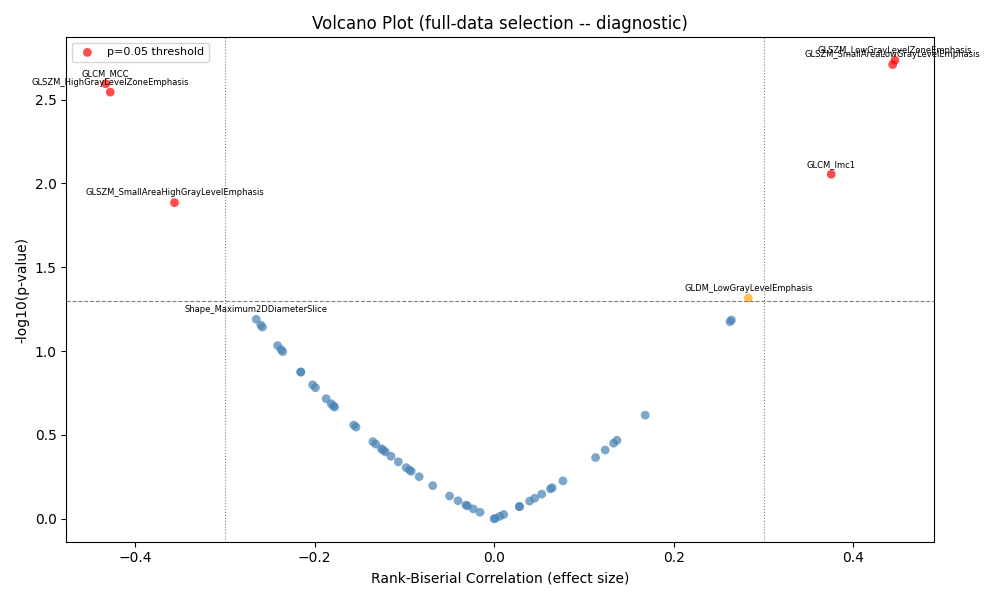


Full-data-selected features (for supplementary): 4
  original_glszm_LowGrayLevelZoneEmphasis
  original_glszm_SmallAreaLowGrayLevelEmphasis
  original_glcm_MCC
  original_glszm_HighGrayLevelZoneEmphasis

Full-data ml_df shape: (195, 8)  (for supplementary use only)


In [13]:
# ============================================================
# BLOCK D: Full-Data Feature Selection -- DIAGNOSTIC ONLY
# ============================================================
# IMPORTANT: This is the "optimistic" full-data pipeline, kept
# for reporting in the supplementary material (to allow direct
# comparison with the nested-CV primary analysis in Block F).
# DO NOT use `selected_features` from this cell for training.
# Block F performs its own per-fold selection from scratch.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from pathlib import Path

# -- Column definitions ------------------------------------
ID_COLS   = ["patient_id", "ln_site", "ln_label"]
LABEL_COL = "metastatic"

# -- Load features -----------------------------------------
if "features_df" not in globals():
    features_df = pd.read_csv("radiomics_features.csv")
    print(f"Loaded {len(features_df)} observations from CSV")

feat_cols = [c for c in features_df.columns if c not in ID_COLS + [LABEL_COL]]

X_raw = features_df[feat_cols].copy()
y     = features_df[LABEL_COL].astype(int)

print(f"Starting features : {X_raw.shape[1]}")
print(f"Observations      : {len(y)}  (metastatic={y.sum()}, benign={len(y)-y.sum()})")

# -- Step 1: Drop non-numeric / high-NaN columns -----------
X_raw = X_raw.apply(pd.to_numeric, errors="coerce")
nan_frac = X_raw.isna().mean()
X = X_raw.loc[:, nan_frac < 0.20].copy()
X = X.fillna(X.median())
print(f"After NaN drop    : {X.shape[1]}")

# -- Step 2: Remove constant / near-constant features ------
stds = X.std()
X = X.loc[:, stds > 1e-6]
print(f"After constant rm : {X.shape[1]}")

# -- Step 3: Remove highly correlated features (|r| > 0.95)
corr_matrix = X.corr(method="spearman").abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
X = X.drop(columns=to_drop_corr)
print(f"After corr drop   : {X.shape[1]}  (removed {len(to_drop_corr)} redundant)")

# -- Step 4: Mann-Whitney U test per feature ---------------
meta_mask   = y == 1
benign_mask = y == 0
X_meta   = X.loc[meta_mask]
X_benign = X.loc[benign_mask]

pvals = []
for col in X.columns:
    _, p = stats.mannwhitneyu(X_meta[col], X_benign[col], alternative="two-sided")
    pvals.append(p)

reject, pvals_adj, _, _ = multipletests(pvals, method="fdr_bh")
mwu_df = pd.DataFrame({
    "feature":           X.columns,
    "p_raw":             pvals,
    "p_adj":             pvals_adj,
    "significant_fdr05": reject,
}).sort_values("p_raw").reset_index(drop=True)

n_sig_raw = (mwu_df["p_raw"] < 0.05).sum()
n_sig_fdr = mwu_df["significant_fdr05"].sum()
print(f"\nMann-Whitney U test (FULL DATA -- diagnostic):")
print(f"  p_raw < 0.05 : {n_sig_raw} features")
print(f"  FDR < 0.05   : {n_sig_fdr} features")
print("\nTop 15 features (by raw p-value):")
print(mwu_df.head(15)[["feature", "p_raw", "p_adj", "significant_fdr05"]].to_string(index=False))

# -- Step 5: Effect size (rank-biserial correlation) --------
def rank_biserial(a, b):
    na, nb = len(a), len(b)
    u, _ = stats.mannwhitneyu(a, b, alternative="two-sided")
    return 1 - (2 * u) / (na * nb)

mwu_df["effect_size"] = [
    rank_biserial(X_meta[c].values, X_benign[c].values)
    for c in mwu_df["feature"]
]

# Save for supplementary table
mwu_df.to_csv("full_data_feature_selection.csv", index=False)

# -- Step 6: Volcano plot ----------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
log_p = -np.log10(mwu_df["p_raw"].clip(lower=1e-10))
es    = mwu_df["effect_size"]

colors = np.where(
    (mwu_df["p_raw"] < 0.05) & (es.abs() > 0.3), "red",
    np.where(mwu_df["p_raw"] < 0.05, "orange", "steelblue")
)
ax.scatter(es, log_p, c=colors, alpha=0.7, s=40, linewidths=0)
ax.axhline(-np.log10(0.05), color="gray", linestyle="--", linewidth=0.8, label="p=0.05")
ax.axvline( 0.3, color="gray", linestyle=":", linewidth=0.8)
ax.axvline(-0.3, color="gray", linestyle=":", linewidth=0.8)
ax.set_xlabel("Rank-Biserial Correlation (effect size)")
ax.set_ylabel("-log10(p-value)")
ax.set_title("Volcano Plot (full-data selection -- diagnostic)")

for _, row in mwu_df.head(8).iterrows():
    short = (row["feature"]
             .replace("original_", "")
             .replace("firstorder_", "FO_")
             .replace("glcm_", "GLCM_")
             .replace("glrlm_", "GLRLM_")
             .replace("glszm_", "GLSZM_")
             .replace("gldm_", "GLDM_")
             .replace("ngtdm_", "NGTDM_")
             .replace("shape_", "Shape_"))
    ax.annotate(short, xy=(row["effect_size"], -np.log10(row["p_raw"])),
                fontsize=6, ha="center", va="bottom",
                xytext=(0, 4), textcoords="offset points")

ax.legend(["p=0.05 threshold"], fontsize=8)
plt.tight_layout()
plt.savefig("volcano_plot.png", dpi=150)
plt.show()

# -- Step 7: Save diagnostic-selected features (supplementary only) --
if n_sig_fdr >= 3:
    fulldata_selected = mwu_df.loc[mwu_df["significant_fdr05"], "feature"].tolist()
else:
    n_top = min(30, len(mwu_df))
    fulldata_selected = mwu_df.head(n_top)["feature"].tolist()

print(f"\nFull-data-selected features (for supplementary): {len(fulldata_selected)}")
for f in fulldata_selected:
    print(f"  {f}")

# Build a ml_df using full-data selection so Block E (70/30 split) can run
# for the supplementary comparison -- this DOES NOT affect Block F nested CV
ml_df = pd.concat([
    features_df[ID_COLS].reset_index(drop=True),
    X[fulldata_selected].reset_index(drop=True),
    y.reset_index(drop=True).rename(LABEL_COL)
], axis=1)
ml_df.to_csv("ml_ready_features_FULLDATA_SELECT.csv", index=False)
print(f"\nFull-data ml_df shape: {ml_df.shape}  (for supplementary use only)")


# 7. Machine Learning Model Training and Evaluation

Features used     : ['original_glszm_LowGrayLevelZoneEmphasis', 'original_glszm_SmallAreaLowGrayLevelEmphasis', 'original_glcm_MCC', 'original_glszm_HighGrayLevelZoneEmphasis']
Observations      : 195  (metastatic=18)

Train: 135 obs, 10 metastatic  (34 patients)
Test : 60  obs, 8  metastatic  (15 patients)

After SMOTE: 250 obs  (metastatic=125, benign=125)

  Logistic Regression
  AUC: 0.575
              precision    recall  f1-score   support

      Benign       0.87      0.50      0.63        52
  Metastatic       0.13      0.50      0.21         8

    accuracy                           0.50        60
   macro avg       0.50      0.50      0.42        60
weighted avg       0.77      0.50      0.58        60


  Random Forest
  AUC: 0.851
              precision    recall  f1-score   support

      Benign       0.95      0.67      0.79        52
  Metastatic       0.26      0.75      0.39         8

    accuracy                           0.68        60
   macro avg       0.60     

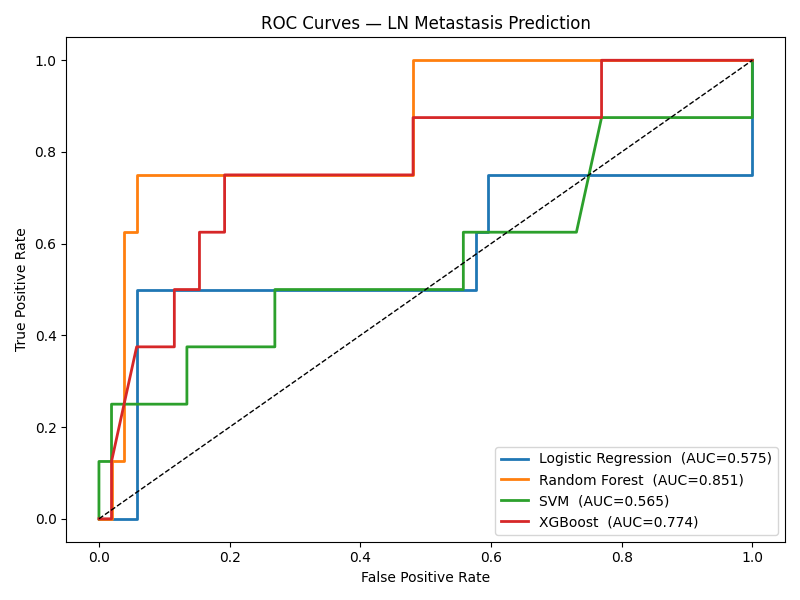

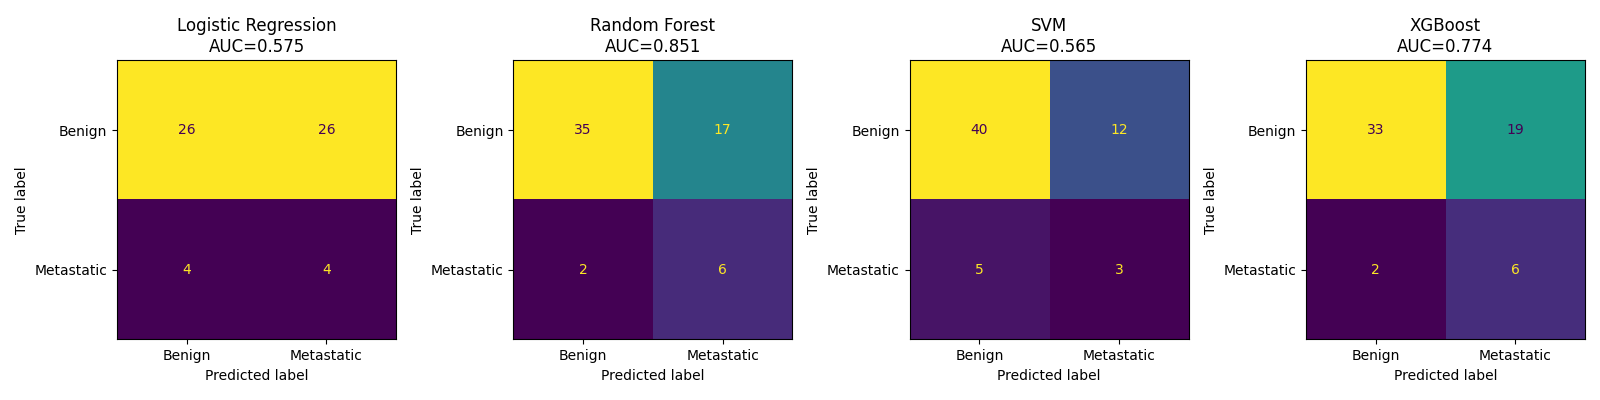

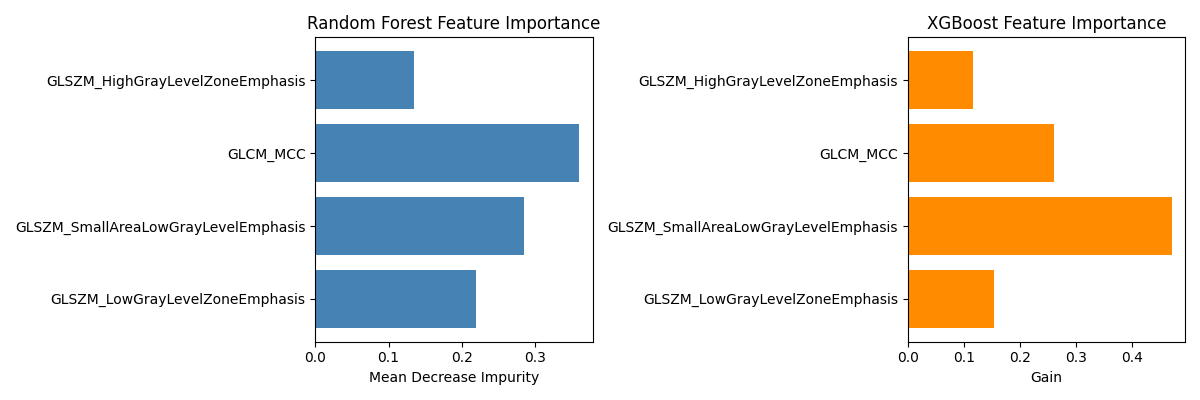


SUMMARY
Model                     AUC    Sens    Spec     PPV     NPV
-------------------------------------------------------
Logistic Regression     0.575   0.500   0.500   0.133   0.867
Random Forest           0.851   0.750   0.673   0.261   0.946
SVM                     0.565   0.375   0.769   0.200   0.889
XGBoost                 0.774   0.750   0.635   0.240   0.943


In [14]:
# ============================================================
# BLOCK E: ML Training & Evaluation  (patient-level 70/30 split)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (roc_auc_score, roc_curve,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb

# ── Load data ──────────────────────────────────────────────
if "ml_df" not in globals():
    ml_df = pd.read_csv("ml_ready_features.csv")
    print(f"Loaded {len(ml_df)} observations from ml_ready_features.csv")

ID_COLS   = ["patient_id", "ln_site", "ln_label"]
LABEL_COL = "metastatic"
feat_cols = [c for c in ml_df.columns if c not in ID_COLS + [LABEL_COL]]

print(f"Features used     : {feat_cols}")
print(f"Observations      : {len(ml_df)}  (metastatic={ml_df[LABEL_COL].sum()})")

# ── Patient-level stratified 70/30 split ───────────────────
# Stratify by whether a patient has ANY metastatic LN
patient_meta = (ml_df.groupby("patient_id")[LABEL_COL]
                .max()
                .reset_index()
                .rename(columns={LABEL_COL: "any_meta"}))

unique_pids   = patient_meta["patient_id"].values
patient_label = patient_meta["any_meta"].values

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
tr_pid_idx, te_pid_idx = next(sss.split(unique_pids, patient_label))

train_pids = set(unique_pids[tr_pid_idx])
test_pids  = set(unique_pids[te_pid_idx])

train_mask = ml_df["patient_id"].isin(train_pids)
test_mask  = ml_df["patient_id"].isin(test_pids)

X_train = ml_df.loc[train_mask, feat_cols].values
y_train = ml_df.loc[train_mask, LABEL_COL].values
X_test  = ml_df.loc[test_mask,  feat_cols].values
y_test  = ml_df.loc[test_mask,  LABEL_COL].values

print(f"\nTrain: {len(y_train)} obs, {y_train.sum()} metastatic  ({len(train_pids)} patients)")
print(f"Test : {len(y_test)}  obs, {y_test.sum()}  metastatic  ({len(test_pids)} patients)")

# ── SMOTE on training set only ──────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=min(4, y_train.sum() - 1))
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)
print(f"\nAfter SMOTE: {len(y_train_bal)} obs  "
      f"(metastatic={y_train_bal.sum()}, benign={len(y_train_bal)-y_train_bal.sum()})")

# ── Model definitions ───────────────────────────────────────
models = {
    "Logistic Regression": LogisticRegression(
        C=0.1, class_weight="balanced", max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=4, class_weight="balanced",
        min_samples_leaf=3, random_state=42),
    "SVM": SVC(
        C=0.5, kernel="rbf", probability=True,
        class_weight="balanced", random_state=42),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        scale_pos_weight=len(y_train)/y_train.sum(),
        use_label_encoder=False, eval_metric="logloss",
        random_state=42, verbosity=0),
}

# ── Train, predict, evaluate ────────────────────────────────
results = {}
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    y_pred = model.predict(X_test_sc)

    auc = roc_auc_score(y_test, y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    cm  = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred,
                                   target_names=["Benign","Metastatic"],
                                   output_dict=True)
    results[name] = {
        "auc": auc, "fpr": fpr, "tpr": tpr,
        "cm": cm, "report": report, "model": model,
        "y_prob": y_prob, "y_pred": y_pred,
    }
    ax_roc.plot(fpr, tpr, lw=2, label=f"{name}  (AUC={auc:.3f})")
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"  AUC: {auc:.3f}")
    print(classification_report(y_test, y_pred,
                                target_names=["Benign","Metastatic"]))

# ROC plot
ax_roc.plot([0,1],[0,1],"k--", lw=1)
ax_roc.set_xlabel("False Positive Rate"); ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curves — LN Metastasis Prediction")
ax_roc.legend(loc="lower right"); plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150); plt.show()

# ── Confusion matrices ──────────────────────────────────────
fig_cm, axes = plt.subplots(1, len(models), figsize=(4*len(models), 4))
for ax, (name, res) in zip(axes, results.items()):
    ConfusionMatrixDisplay(res["cm"],
                           display_labels=["Benign","Metastatic"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name}\nAUC={res['auc']:.3f}")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150); plt.show()

# ── Feature importance ──────────────────────────────────────
fig_fi, axes = plt.subplots(1, 2, figsize=(12, 4))
short_names = [f.replace("original_","").replace("glszm_","GLSZM_")
                .replace("glcm_","GLCM_").replace("gldm_","GLDM_") for f in feat_cols]

# Random Forest importances
rf_imp = results["Random Forest"]["model"].feature_importances_
axes[0].barh(short_names, rf_imp, color="steelblue")
axes[0].set_title("Random Forest Feature Importance")
axes[0].set_xlabel("Mean Decrease Impurity")

# XGBoost importances
xgb_imp = results["XGBoost"]["model"].feature_importances_
axes[1].barh(short_names, xgb_imp, color="darkorange")
axes[1].set_title("XGBoost Feature Importance")
axes[1].set_xlabel("Gain")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150); plt.show()

# ── Summary table ───────────────────────────────────────────
print(f"\n{'='*55}")
print("SUMMARY")
print(f"{'Model':<22} {'AUC':>6}  {'Sens':>6}  {'Spec':>6}  {'PPV':>6}  {'NPV':>6}")
print("-"*55)
for name, res in results.items():
    rep = res["report"]
    sens = rep["Metastatic"]["recall"]
    ppv  = rep["Metastatic"]["precision"]
    spec = rep["Benign"]["recall"]
    tp   = res["cm"][1,1]; fn = res["cm"][1,0]
    tn   = res["cm"][0,0]; fp = res["cm"][0,1]
    npv  = tn/(tn+fn) if (tn+fn) > 0 else float("nan")
    print(f"{name:<22} {res['auc']:>6.3f}  {sens:>6.3f}  {spec:>6.3f}  {ppv:>6.3f}  {npv:>6.3f}")


### Bootstrap Confidence Intervals      


In [15]:
# Bootstrap 95% CI on AUC for Random Forest
from sklearn.utils import resample

rf_probs = results["Random Forest"]["y_prob"]
boot_aucs = []
np.random.seed(42)
for _ in range(2000):
    idx = resample(range(len(y_test)))
    if len(np.unique(y_test[idx])) < 2:
        continue
    boot_aucs.append(roc_auc_score(y_test[idx], rf_probs[idx]))

lo, hi = np.percentile(boot_aucs, [2.5, 97.5])
print(f"Random Forest AUC = 0.851 (95% CI: {lo:.3f}–{hi:.3f})")



Random Forest AUC = 0.851 (95% CI: 0.690–0.982)


## Leave-One-Out-Cross-Validation (LOOCV)

Nested LOOCV: 49 folds | 195 observations | 18 metastatic
Starting feature pool: 107

Block F device config: USE_GPU=True | xgb.device='cuda' | xgb.tree_method='hist'
  [ 5/49] last: 256069 (meta=0/4, n_feat=3)
  [10/49] last: 662134 (meta=1/4, n_feat=10 fallback)
  [15/49] last: 669720 (meta=0/4, n_feat=4)
  [20/49] last: 637045 (meta=0/4, n_feat=4)
  [25/49] last: 667223 (meta=0/4, n_feat=4)
  [30/49] last: 636235 (meta=0/4, n_feat=10 fallback)
  [35/49] last: 624950 (meta=1/4, n_feat=5)
  [40/49] last: 621897 (meta=0/4, n_feat=4)
  [45/49] last: 405570 (meta=1/4, n_feat=4)
  [49/49] last: 656758 (meta=1/4, n_feat=5)

Folds using top-10 fallback: 14/49
Saved nested_loocv_oof_predictions.csv
Saved feature_selection_stability.csv and feature_selection_frequency.csv

NESTED LOOCV SUMMARY (feature selection per-fold, train-only)

Logistic Regression
  AUC            : 0.522  (95% CI: 0.322-0.746)
  Youden threshold: 0.289
  Sensitivity    : 0.833  (15/18 metastatic detected)
  Specificit

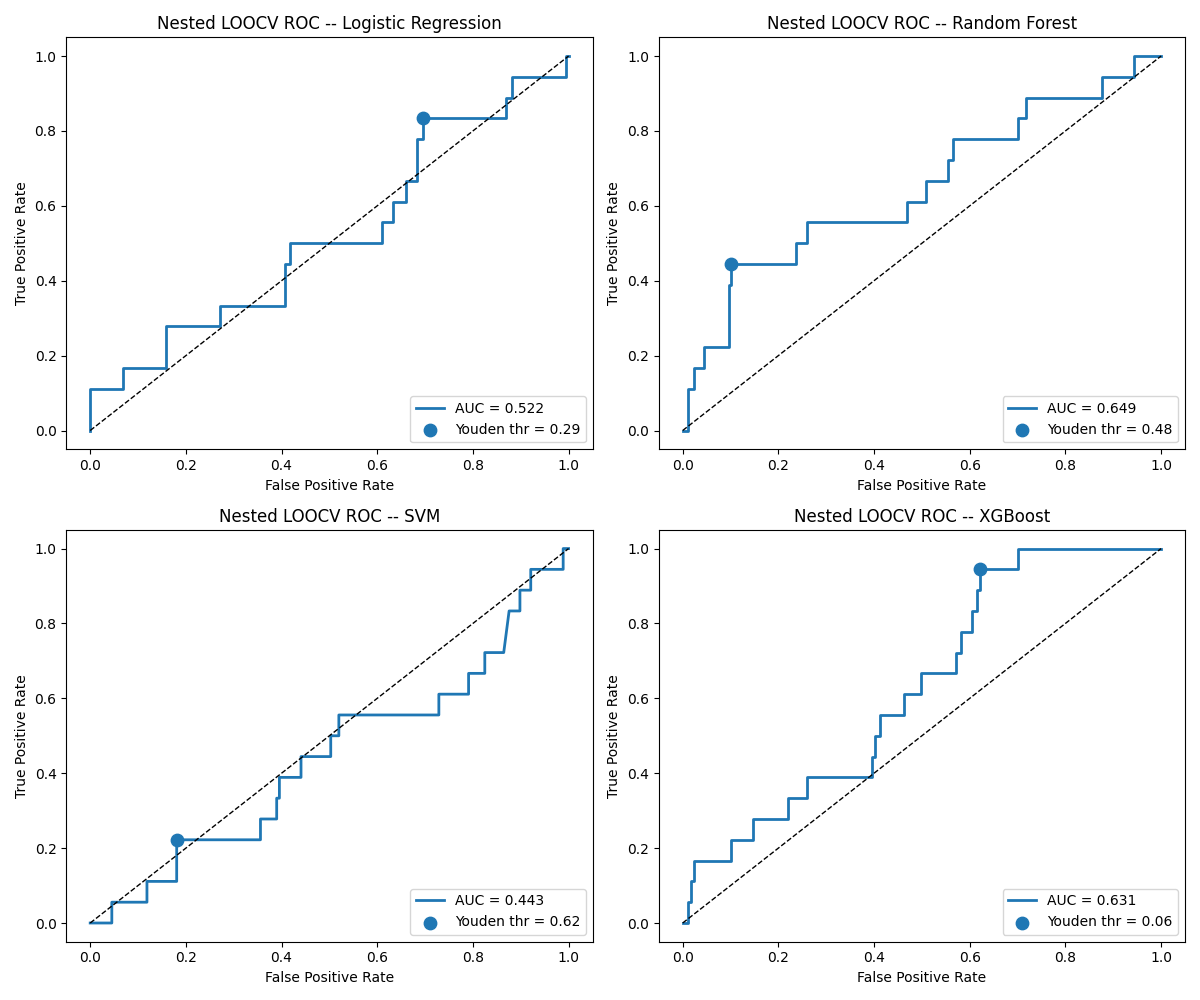

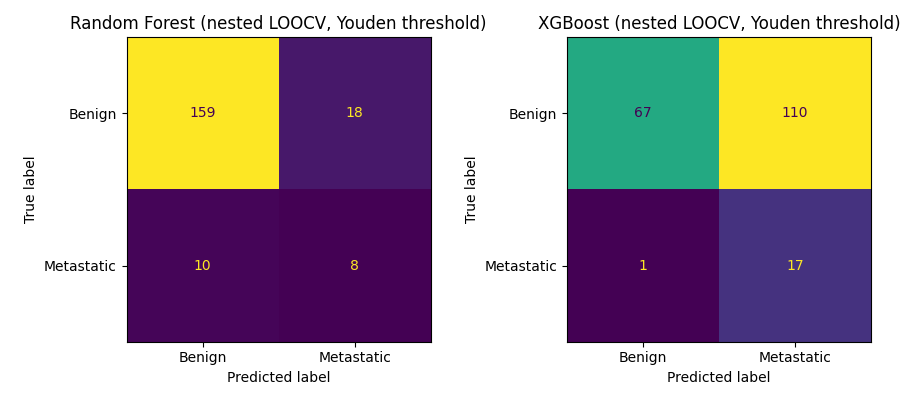

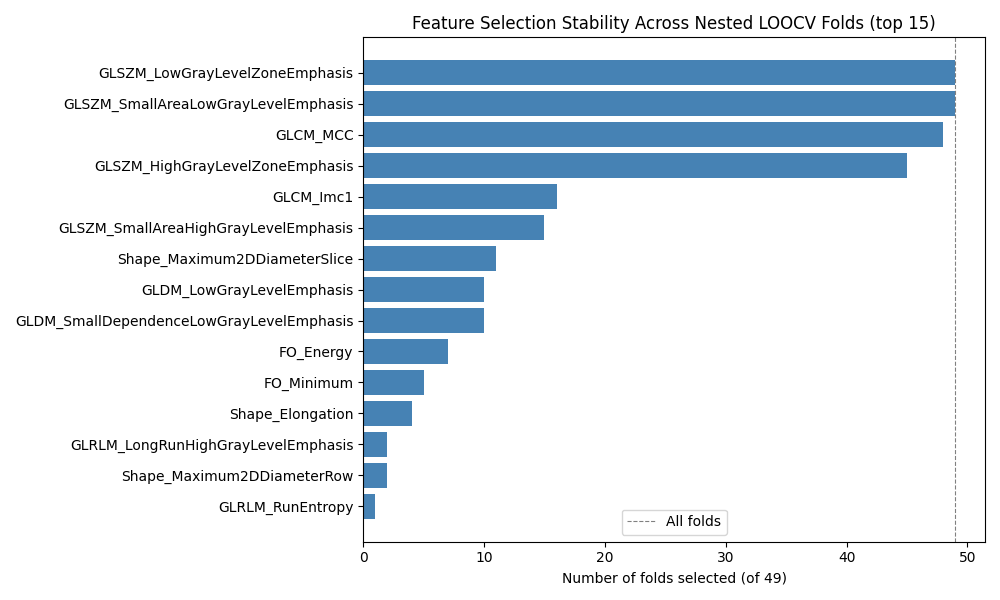


Done. Saved figures: nested_loocv_roc.png, nested_loocv_confusion.png, feature_selection_stability.png


In [16]:
# ============================================================
# BLOCK F: Nested Leave-One-Patient-Out Cross-Validation (LOOCV)
# ============================================================
# Feature selection is performed INSIDE each LOOCV fold on
# training data only. The held-out patient is never observed
# during selection, scaling, or SMOTE.
# This is the primary analysis for the revised manuscript.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

# -- Load raw features (NOT ml_df -- we select inside the loop) --
if "features_df" not in globals():
    features_df = pd.read_csv("radiomics_features.csv")

ID_COLS   = ["patient_id", "ln_site", "ln_label"]
LABEL_COL = "metastatic"
feat_cols_all = [c for c in features_df.columns if c not in ID_COLS + [LABEL_COL]]

unique_pids = features_df["patient_id"].unique()
print(f"Nested LOOCV: {len(unique_pids)} folds | "
      f"{len(features_df)} observations | {features_df[LABEL_COL].sum()} metastatic")
print(f"Starting feature pool: {len(feat_cols_all)}\n")

RNG_SEED = 42


# -- Per-fold feature selection (train-only) ------------------
def select_features_train_only(X_train, y_train,
                               fdr_q=0.05, top_n_fallback=10,
                               corr_thresh=0.95, var_thresh=1e-6):
    """Run the 3-step selection pipeline on training data only."""
    # 1a: drop near-constant features
    stds = X_train.std()
    X = X_train[stds[stds > var_thresh].index]

    # 1b: drop highly correlated features
    if X.shape[1] > 1:
        corr = X.corr(method="spearman").abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        drop = [c for c in upper.columns if any(upper[c] > corr_thresh)]
        X = X.drop(columns=drop)

    # 2: Mann-Whitney U + BH-FDR
    pvals = []
    for c in X.columns:
        meta = X.loc[y_train == 1, c].values
        ben  = X.loc[y_train == 0, c].values
        if len(np.unique(np.concatenate([meta, ben]))) < 2:
            pvals.append(1.0)
            continue
        try:
            _, p = stats.mannwhitneyu(meta, ben, alternative="two-sided")
        except Exception:
            p = 1.0
        pvals.append(p)
    pvals = np.array(pvals)

    if len(pvals) == 0:
        return [], 0

    reject, _, _, _ = multipletests(pvals, alpha=fdr_q, method="fdr_bh")
    sig = X.columns[reject].tolist()
    used_fallback = 0

    # Fallback: if <3 FDR-significant features, take top-N by raw p
    if len(sig) < 3:
        order = np.argsort(pvals)
        sig = X.columns[order][:min(top_n_fallback, len(pvals))].tolist()
        used_fallback = 1

    return sig, used_fallback


# -- Models to evaluate -------------------------------------
# Resolve GPU config from the check cell (fallback to CPU if not run yet).
_XGB_DEVICE      = globals().get("XGB_DEVICE",      "cpu")
_XGB_TREE_METHOD = globals().get("XGB_TREE_METHOD", "hist")
_USE_GPU         = globals().get("USE_GPU",         False)
print(f"Block F device config: USE_GPU={_USE_GPU} | "
      f"xgb.device={_XGB_DEVICE!r} | xgb.tree_method={_XGB_TREE_METHOD!r}")
# sklearn models stay on CPU (cuML is not reliably available on Windows).
# RandomForest uses all cores (n_jobs=-1) for CPU parallelism.


def make_models(scale_pos_weight=1.0):
    return {
        "Logistic Regression": LogisticRegression(
            C=0.1, class_weight="balanced", max_iter=1000,
            random_state=RNG_SEED),
        "Random Forest": RandomForestClassifier(
            n_estimators=200, max_depth=4, class_weight="balanced",
            min_samples_leaf=3, random_state=RNG_SEED, n_jobs=-1),
        "SVM": SVC(
            C=0.5, kernel="rbf", probability=True,
            class_weight="balanced", random_state=RNG_SEED),
        "XGBoost": xgb.XGBClassifier(
            n_estimators=100, max_depth=3, learning_rate=0.05,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            device=_XGB_DEVICE, tree_method=_XGB_TREE_METHOD,
            random_state=RNG_SEED, verbosity=0, n_jobs=1),
    }


model_names = list(make_models().keys())
oof = {n: {"y_true": [], "y_prob": [], "patient_id": [], "ln_site": []}
       for n in model_names}

selection_log = []
n_fallback_folds = 0

# -- Nested LOOCV loop --------------------------------------
for i, test_pid in enumerate(unique_pids):
    train_mask = features_df["patient_id"] != test_pid
    test_mask  = features_df["patient_id"] == test_pid

    X_tr_full = features_df.loc[train_mask, feat_cols_all].apply(pd.to_numeric, errors="coerce")
    y_tr      = features_df.loc[train_mask, LABEL_COL].astype(int).values
    X_te_full = features_df.loc[test_mask,  feat_cols_all].apply(pd.to_numeric, errors="coerce")
    y_te      = features_df.loc[test_mask,  LABEL_COL].astype(int).values

    # Impute (training-median only) before selection
    nan_frac = X_tr_full.isna().mean()
    good_cols = nan_frac[nan_frac < 0.20].index
    X_tr_full = X_tr_full[good_cols]
    X_te_full = X_te_full[good_cols]
    med = X_tr_full.median()
    X_tr_full = X_tr_full.fillna(med)
    X_te_full = X_te_full.fillna(med)

    # Per-fold feature selection
    selected, used_fb = select_features_train_only(X_tr_full, y_tr)
    n_fallback_folds += used_fb
    selection_log.append({
        "test_pid":     test_pid,
        "n_selected":   len(selected),
        "used_fallback": used_fb,
        "features":     ";".join(selected),
    })

    if not selected:
        print(f"  [{i+1:2d}/{len(unique_pids)}] {test_pid}: no features selected -- SKIP")
        continue

    X_tr = X_tr_full[selected].values
    X_te = X_te_full[selected].values

    # Scale (fit on train only)
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    # SMOTE (train only)
    n_pos = int(y_tr.sum())
    if n_pos < 2:
        print(f"  [{i+1:2d}/{len(unique_pids)}] {test_pid}: <2 positives -- SKIP")
        continue
    k = min(4, n_pos - 1)
    try:
        X_bal, y_bal = SMOTE(random_state=RNG_SEED, k_neighbors=k).fit_resample(X_tr_s, y_tr)
    except Exception as e:
        print(f"  [{i+1:2d}/{len(unique_pids)}] {test_pid}: SMOTE failed ({e}) -- raw train")
        X_bal, y_bal = X_tr_s, y_tr

    spw = max(1, (len(y_bal) - y_bal.sum()) / max(y_bal.sum(), 1))
    models = make_models(scale_pos_weight=spw)

    for name, mdl in models.items():
        try:
            mdl.fit(X_bal, y_bal)
            probs = mdl.predict_proba(X_te_s)[:, 1]
        except Exception as e:
            print(f"    {name} failed on fold {test_pid}: {e}")
            probs = np.full(len(y_te), 0.5)
        oof[name]["y_true"].extend(y_te.tolist())
        oof[name]["y_prob"].extend(probs.tolist())
        oof[name]["patient_id"].extend([test_pid] * len(y_te))
        oof[name]["ln_site"].extend(features_df.loc[test_mask, "ln_site"].tolist())

    if (i + 1) % 5 == 0 or (i + 1) == len(unique_pids):
        print(f"  [{i+1:2d}/{len(unique_pids)}] last: {test_pid} "
              f"(meta={int(y_te.sum())}/{len(y_te)}, n_feat={len(selected)}"
              f"{' fallback' if used_fb else ''})")

print(f"\nFolds using top-10 fallback: {n_fallback_folds}/{len(unique_pids)}")


# -- Save OOF predictions -----------------------------------
oof_rows = []
for name, d in oof.items():
    for j in range(len(d["y_true"])):
        oof_rows.append({
            "model":      name,
            "patient_id": d["patient_id"][j],
            "ln_site":    d["ln_site"][j],
            "y_true":     d["y_true"][j],
            "y_prob":     d["y_prob"][j],
        })
pd.DataFrame(oof_rows).to_csv("nested_loocv_oof_predictions.csv", index=False)
print("Saved nested_loocv_oof_predictions.csv")

# -- Save per-fold selection log & frequency table ----------
selection_df = pd.DataFrame(selection_log)
selection_df.to_csv("feature_selection_stability.csv", index=False)

from collections import Counter
feat_counter = Counter()
for f_str in selection_df["features"]:
    if f_str:
        for f in f_str.split(";"):
            feat_counter[f] += 1
stab = pd.DataFrame(
    [{"feature": f, "n_folds_selected": n,
      "selection_freq": round(n / len(selection_df), 3)}
     for f, n in feat_counter.most_common()]
)
stab.to_csv("feature_selection_frequency.csv", index=False)
print("Saved feature_selection_stability.csv and feature_selection_frequency.csv")


# -- Patient-level bootstrap CI helper ----------------------
def patient_bootstrap_ci(y_true, y_prob, pids, n_boot=5000, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    pids = np.asarray(pids)
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    upids = np.unique(pids)
    aucs = []
    for _ in range(n_boot):
        sampled = rng.choice(upids, size=len(upids), replace=True)
        bt, bp = [], []
        for p in sampled:
            idx = np.where(pids == p)[0]
            bt.append(y_true[idx]); bp.append(y_prob[idx])
        bt = np.concatenate(bt); bp = np.concatenate(bp)
        if len(np.unique(bt)) < 2:
            continue
        aucs.append(roc_auc_score(bt, bp))
    aucs = np.array(aucs)
    return aucs.mean(), np.percentile(aucs, [2.5, 97.5])


# -- Summary with CIs and Youden-optimal operating points ---
print(f"\n{'='*78}")
print("NESTED LOOCV SUMMARY (feature selection per-fold, train-only)")
print(f"{'='*78}")

summary_rows = []
for name, d in oof.items():
    if not d["y_true"]:
        continue
    y_true = np.array(d["y_true"])
    y_prob = np.array(d["y_prob"])
    pids   = np.array(d["patient_id"])

    auc = roc_auc_score(y_true, y_prob)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    best = int(np.argmax(tpr - fpr))
    thr_best = thr[best]
    y_pred = (y_prob >= thr_best).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    ppv  = tp / (tp + fp) if (tp + fp) else np.nan
    npv  = tn / (tn + fn) if (tn + fn) else np.nan

    mean_auc, (lo, hi) = patient_bootstrap_ci(y_true, y_prob, pids, n_boot=5000)

    print(f"\n{name}")
    print(f"  AUC            : {auc:.3f}  (95% CI: {lo:.3f}-{hi:.3f})")
    print(f"  Youden threshold: {thr_best:.3f}")
    print(f"  Sensitivity    : {sens:.3f}  ({tp}/{tp+fn} metastatic detected)")
    print(f"  Specificity    : {spec:.3f}")
    print(f"  PPV            : {ppv:.3f}")
    print(f"  NPV            : {npv:.3f}")

    summary_rows.append({
        "model":       name,
        "auc":         round(auc, 3),
        "ci_low":      round(lo, 3),
        "ci_high":     round(hi, 3),
        "youden_thr":  round(thr_best, 3),
        "sens":        round(sens, 3),
        "spec":        round(spec, 3),
        "ppv":         round(ppv, 3),
        "npv":         round(npv, 3),
        "tp": int(tp), "fn": int(fn), "tn": int(tn), "fp": int(fp),
    })

pd.DataFrame(summary_rows).to_csv("nested_loocv_summary.csv", index=False)
print("\nSaved nested_loocv_summary.csv")


# -- Figures: ROC curves and confusion matrices -------------
# 4-panel ROC for all four models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, d) in zip(axes.ravel(), oof.items()):
    if not d["y_true"]:
        ax.set_title(f"{name} (no data)"); continue
    y_true = np.array(d["y_true"]); y_prob = np.array(d["y_prob"])
    auc = roc_auc_score(y_true, y_prob)
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    best = int(np.argmax(tpr - fpr))
    ax.plot(fpr, tpr, lw=2, label=f"AUC = {auc:.3f}")
    ax.scatter(fpr[best], tpr[best], s=80, zorder=5,
               label=f"Youden thr = {thr[best]:.2f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title(f"Nested LOOCV ROC -- {name}")
    ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("nested_loocv_roc.png", dpi=150)
plt.show()

# Confusion matrices for RF and XGBoost at Youden threshold
key_models = ["Random Forest", "XGBoost"]
fig2, axes2 = plt.subplots(1, 2, figsize=(9, 4))
for ax, name in zip(axes2, key_models):
    d = oof[name]
    if not d["y_true"]: continue
    y_true = np.array(d["y_true"]); y_prob = np.array(d["y_prob"])
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    thr_best = thr[int(np.argmax(tpr - fpr))]
    y_pred = (y_prob >= thr_best).astype(int)
    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=["Benign", "Metastatic"],
    ).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name} (nested LOOCV, Youden threshold)")
plt.tight_layout()
plt.savefig("nested_loocv_confusion.png", dpi=150)
plt.show()

# Selection frequency bar chart (top 15)
fig3, ax3 = plt.subplots(figsize=(10, 6))
top = stab.head(15).iloc[::-1]
short_names = [
    (f.replace("original_", "")
      .replace("firstorder_", "FO_")
      .replace("glcm_",  "GLCM_")
      .replace("glrlm_", "GLRLM_")
      .replace("glszm_", "GLSZM_")
      .replace("gldm_",  "GLDM_")
      .replace("ngtdm_", "NGTDM_")
      .replace("shape_", "Shape_"))
    for f in top["feature"]
]
ax3.barh(short_names, top["n_folds_selected"], color="steelblue")
ax3.set_xlabel(f"Number of folds selected (of {len(selection_df)})")
ax3.set_title("Feature Selection Stability Across Nested LOOCV Folds (top 15)")
ax3.axvline(len(selection_df), color="gray", linestyle="--", linewidth=0.8, label="All folds")
ax3.legend()
plt.tight_layout()
plt.savefig("feature_selection_stability.png", dpi=150)
plt.show()

print("\nDone. Saved figures: nested_loocv_roc.png, nested_loocv_confusion.png, "
      "feature_selection_stability.png")


Repeated StratifiedGroupKFold sensitivity analysis
  n_repeats x n_splits = 20 x 5 = 100 folds
  195 observations across 49 patients (18 metastatic)

  repeat 5/20 done
  repeat 10/20 done
  repeat 15/20 done
  repeat 20/20 done

Saved repeated_groupkfold_per_fold.csv  (396 rows)

Repeated 5-fold StratifiedGroupKFold summary (20 repeats):
              model  n_folds  auc_mean  auc_median  auc_std  auc_p2.5  auc_p97.5  fallback_rate
      Random Forest       99     0.670       0.702    0.194     0.293      0.964          0.717
            XGBoost       99     0.642       0.618    0.182     0.306      0.965          0.717
Logistic Regression       99     0.560       0.597    0.216     0.188      0.963          0.717
                SVM       99     0.544       0.549    0.184     0.174      0.952          0.717

Nested LOOCV vs Repeated GroupKFold (AUC):
              model  loocv_auc  loocv_ci_low  loocv_ci_high  auc_mean  auc_p2.5  auc_p97.5
      Random Forest      0.649         0.474

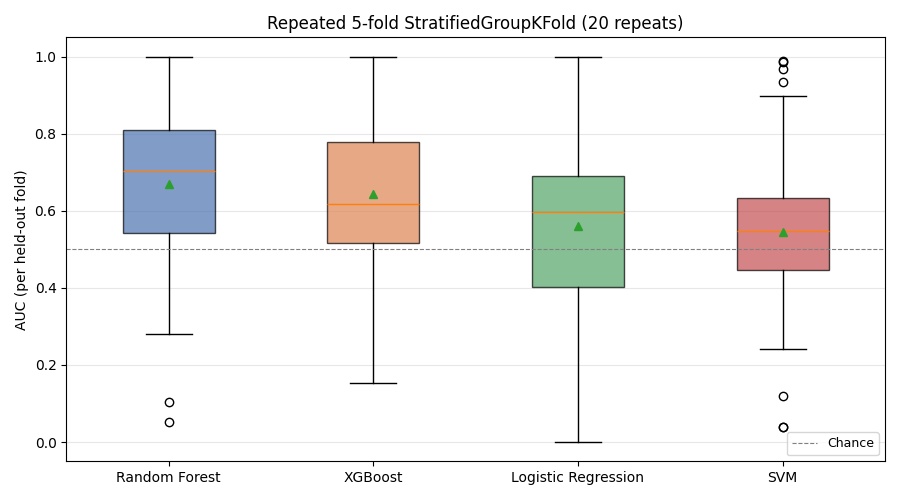


Done. Files written:
  repeated_groupkfold_per_fold.csv
  repeated_groupkfold_summary.csv
  auc_loocv_vs_groupkfold.csv  (if Block F ran first)
  repeated_groupkfold_boxplot.png


In [17]:
# ============================================================
# BLOCK F2: Repeated 5-Fold StratifiedGroupKFold (sensitivity analysis)
# ============================================================
# Sensitivity analysis complementing the nested LOOCV in Block F.
# - Groups observations by patient_id (no patient appears in both train/test)
# - Stratifies on the observation-level metastatic label
# - Runs N_REPEATS = 20 independent seeds x 5 folds = 100 held-out folds
# - Same per-fold pipeline as Block F: feature selection on TRAIN only,
#   scale on TRAIN only, SMOTE on TRAIN only
# Yields tighter, lower-variance AUC estimates than LOOCV for small cohorts.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

# Block F must have run first -- we reuse select_features_train_only,
# make_models, features_df, feat_cols_all, ID_COLS, LABEL_COL, RNG_SEED.
for _needed in ("select_features_train_only", "make_models",
                "features_df", "feat_cols_all", "RNG_SEED"):
    if _needed not in globals():
        raise RuntimeError(f"Run Block F before Block F2 (missing: {_needed})")

N_REPEATS = 20
N_SPLITS  = 5

model_names = list(make_models().keys())
per_fold_rows = []   # (model, repeat, fold, auc, n_test_meta, n_test_total, n_feat_selected, used_fallback)

n_positives = int(features_df[LABEL_COL].sum())
print(f"Repeated StratifiedGroupKFold sensitivity analysis")
print(f"  n_repeats x n_splits = {N_REPEATS} x {N_SPLITS} = {N_REPEATS*N_SPLITS} folds")
print(f"  {len(features_df)} observations across "
      f"{features_df['patient_id'].nunique()} patients "
      f"({n_positives} metastatic)\n")

X_all = features_df[feat_cols_all]
y_all = features_df[LABEL_COL].astype(int).values
groups = features_df["patient_id"].values

for rep in range(N_REPEATS):
    sgkf = StratifiedGroupKFold(
        n_splits=N_SPLITS, shuffle=True, random_state=RNG_SEED + rep
    )
    for fold_idx, (tr_idx, te_idx) in enumerate(sgkf.split(X_all, y_all, groups)):
        X_tr_full = X_all.iloc[tr_idx].apply(pd.to_numeric, errors="coerce")
        X_te_full = X_all.iloc[te_idx].apply(pd.to_numeric, errors="coerce")
        y_tr, y_te = y_all[tr_idx], y_all[te_idx]

        # Skip folds with no test positives -- AUC undefined
        if len(np.unique(y_te)) < 2:
            continue

        # Impute on TRAIN median only
        nan_frac = X_tr_full.isna().mean()
        good_cols = nan_frac[nan_frac < 0.20].index
        X_tr_full = X_tr_full[good_cols]
        X_te_full = X_te_full[good_cols]
        med = X_tr_full.median()
        X_tr_full = X_tr_full.fillna(med)
        X_te_full = X_te_full.fillna(med)

        selected, used_fb = select_features_train_only(X_tr_full, y_tr)
        if not selected:
            continue

        X_tr = X_tr_full[selected].values
        X_te = X_te_full[selected].values

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        # SMOTE on TRAIN only
        n_pos_tr = int(y_tr.sum())
        if n_pos_tr < 2:
            X_bal, y_bal = X_tr_s, y_tr
        else:
            k = min(4, n_pos_tr - 1)
            try:
                X_bal, y_bal = SMOTE(
                    random_state=RNG_SEED + rep, k_neighbors=k
                ).fit_resample(X_tr_s, y_tr)
            except Exception:
                X_bal, y_bal = X_tr_s, y_tr

        spw = max(1, (len(y_bal) - y_bal.sum()) / max(y_bal.sum(), 1))
        models = make_models(scale_pos_weight=spw)

        for name, mdl in models.items():
            try:
                mdl.fit(X_bal, y_bal)
                probs = mdl.predict_proba(X_te_s)[:, 1]
                auc = roc_auc_score(y_te, probs)
            except Exception:
                continue
            per_fold_rows.append({
                "model":          name,
                "repeat":         rep,
                "fold":           fold_idx,
                "auc":            auc,
                "n_test_meta":    int(y_te.sum()),
                "n_test_total":   int(len(y_te)),
                "n_feat":         len(selected),
                "used_fallback":  int(used_fb),
            })
    if (rep + 1) % 5 == 0:
        print(f"  repeat {rep+1}/{N_REPEATS} done")

per_fold_df = pd.DataFrame(per_fold_rows)
per_fold_df.to_csv("repeated_groupkfold_per_fold.csv", index=False)
print(f"\nSaved repeated_groupkfold_per_fold.csv  ({len(per_fold_df)} rows)")

# -- Aggregate summary --------------------------------------
summary_rows = []
for name, sub in per_fold_df.groupby("model"):
    aucs = sub["auc"].values
    summary_rows.append({
        "model":            name,
        "n_folds":          len(aucs),
        "auc_mean":         round(float(np.mean(aucs)),   3),
        "auc_median":       round(float(np.median(aucs)), 3),
        "auc_std":          round(float(np.std(aucs,  ddof=1)), 3),
        "auc_p2.5":         round(float(np.percentile(aucs,  2.5)), 3),
        "auc_p97.5":        round(float(np.percentile(aucs, 97.5)), 3),
        "fallback_rate":    round(float(sub["used_fallback"].mean()), 3),
    })
summary_df = pd.DataFrame(summary_rows).sort_values("auc_mean", ascending=False)
summary_df.to_csv("repeated_groupkfold_summary.csv", index=False)

print("\nRepeated 5-fold StratifiedGroupKFold summary (20 repeats):")
print(summary_df.to_string(index=False))

# -- Comparison vs nested LOOCV (Block F) -------------------
loocv_path = Path("nested_loocv_summary.csv")
if loocv_path.exists():
    loocv = pd.read_csv(loocv_path)[["model", "auc", "ci_low", "ci_high"]]
    loocv = loocv.rename(columns={"auc": "loocv_auc",
                                  "ci_low": "loocv_ci_low",
                                  "ci_high": "loocv_ci_high"})
    merged = summary_df.merge(loocv, on="model", how="left")
    print("\nNested LOOCV vs Repeated GroupKFold (AUC):")
    print(merged[["model", "loocv_auc", "loocv_ci_low", "loocv_ci_high",
                  "auc_mean", "auc_p2.5", "auc_p97.5"]].to_string(index=False))
    merged.to_csv("auc_loocv_vs_groupkfold.csv", index=False)

# -- Box plot of per-fold AUCs per model --------------------
fig, ax = plt.subplots(figsize=(9, 5))
order = summary_df["model"].tolist()
data = [per_fold_df.loc[per_fold_df["model"] == m, "auc"].values for m in order]
bp = ax.boxplot(data, labels=order, patch_artist=True, showmeans=True)
for patch, color in zip(bp["boxes"],
                        ["#4C72B0", "#DD8452", "#55A467", "#C44E52"]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=0.8, label="Chance")
ax.set_ylabel("AUC (per held-out fold)")
ax.set_title(f"Repeated 5-fold StratifiedGroupKFold ({N_REPEATS} repeats)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("repeated_groupkfold_boxplot.png", dpi=150)
plt.show()

print("\nDone. Files written:")
print("  repeated_groupkfold_per_fold.csv")
print("  repeated_groupkfold_summary.csv")
print("  auc_loocv_vs_groupkfold.csv  (if Block F ran first)")
print("  repeated_groupkfold_boxplot.png")


Bootstrap CI — 5000 iterations, patient-level resampling

Logistic Regression
  AUC             : 0.522
  95% CI          : 0.322 – 0.746
  SE              : 0.109
  Valid bootstraps: 5000/5000  (degenerate skipped: 0)

Random Forest
  AUC             : 0.649
  95% CI          : 0.477 – 0.828
  SE              : 0.089
  Valid bootstraps: 5000/5000  (degenerate skipped: 0)

SVM
  AUC             : 0.443
  95% CI          : 0.265 – 0.681
  SE              : 0.105
  Valid bootstraps: 5000/5000  (degenerate skipped: 0)

XGBoost
  AUC             : 0.631
  95% CI          : 0.505 – 0.769
  SE              : 0.067
  Valid bootstraps: 5000/5000  (degenerate skipped: 0)



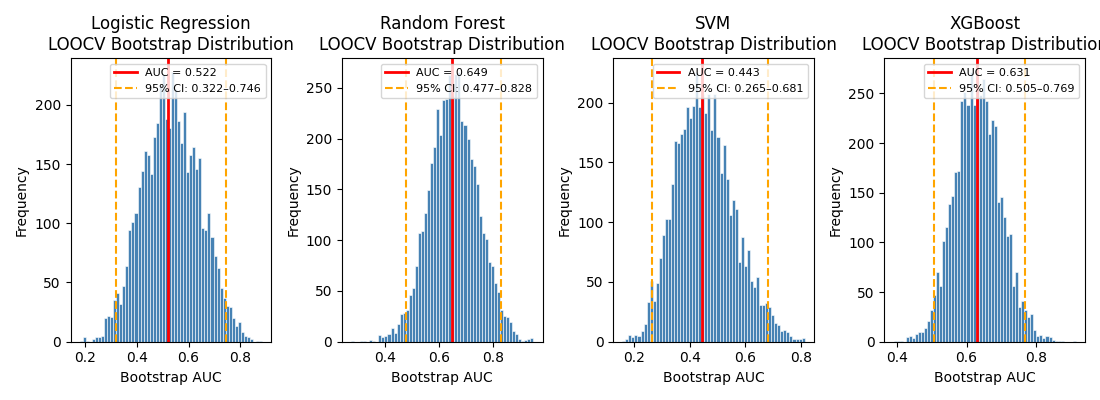

REPORTABLE RESULTS
Logistic Regression     AUC = 0.522  (95% CI: 0.322–0.746)
Random Forest           AUC = 0.649  (95% CI: 0.477–0.828)
SVM                     AUC = 0.443  (95% CI: 0.265–0.681)
XGBoost                 AUC = 0.631  (95% CI: 0.505–0.769)


In [18]:
# ============================================================
# BLOCK G: Bootstrap 95% CI on LOOCV AUC (patient-level)
# ============================================================
# Bootstraps at the PATIENT level (not observation level) to
# preserve within-patient correlation between LN observations.
# ============================================================

import numpy as np
from sklearn.metrics import roc_auc_score

N_BOOTSTRAP = 5000
RNG = np.random.default_rng(42)

# Verify OOF predictions are available
if "oof" not in globals():
    raise RuntimeError("Run Block F (LOOCV) first — 'oof' dict not found.")

print(f"Bootstrap CI — {N_BOOTSTRAP} iterations, patient-level resampling\n")

summary = {}

for model_name, data in oof.items():
    y_true  = np.array(data["y_true"])
    y_prob  = np.array(data["y_prob"])
    pids    = np.array(data["patient_id"])

    unique_pids = np.unique(pids)
    n_patients  = len(unique_pids)

    # Point estimate (already computed but recalculate here for clarity)
    point_auc = roc_auc_score(y_true, y_prob)

    boot_aucs = []
    degenerate = 0  # folds where resampled set has only one class

    for _ in range(N_BOOTSTRAP):
        # Resample patients WITH replacement
        sampled_pids = RNG.choice(unique_pids, size=n_patients, replace=True)

        # Collect all observations for the sampled patients
        boot_mask = np.isin(pids, sampled_pids)

        # If a patient appears k times, include their observations k times
        boot_true, boot_prob = [], []
        for pid in sampled_pids:
            idx = np.where(pids == pid)[0]
            boot_true.append(y_true[idx])
            boot_prob.append(y_prob[idx])

        bt = np.concatenate(boot_true)
        bp = np.concatenate(boot_prob)

        # Skip if only one class present in this resample
        if len(np.unique(bt)) < 2:
            degenerate += 1
            continue

        boot_aucs.append(roc_auc_score(bt, bp))

    boot_aucs = np.array(boot_aucs)
    ci_lo, ci_hi = np.percentile(boot_aucs, [2.5, 97.5])
    se = boot_aucs.std()

    summary[model_name] = {
        "point": point_auc,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi,
        "se": se,
        "boot_aucs": boot_aucs,
    }

    print(f"{model_name}")
    print(f"  AUC             : {point_auc:.3f}")
    print(f"  95% CI          : {ci_lo:.3f} – {ci_hi:.3f}")
    print(f"  SE              : {se:.3f}")
    print(f"  Valid bootstraps: {len(boot_aucs)}/{N_BOOTSTRAP}"
          f"  (degenerate skipped: {degenerate})\n")

# ── Distribution plot ───────────────────────────────────────
fig, axes = plt.subplots(1, len(summary), figsize=(11, 4))

for ax, (name, res) in zip(axes, summary.items()):
    ax.hist(res["boot_aucs"], bins=60, color="steelblue",
            edgecolor="white", linewidth=0.4)
    ax.axvline(res["point"], color="red",    lw=2,
               label=f"AUC = {res['point']:.3f}")
    ax.axvline(res["ci_lo"], color="orange", lw=1.5,
               linestyle="--", label=f"95% CI: {res['ci_lo']:.3f}–{res['ci_hi']:.3f}")
    ax.axvline(res["ci_hi"], color="orange", lw=1.5, linestyle="--")
    ax.set_xlabel("Bootstrap AUC")
    ax.set_ylabel("Frequency")
    ax.set_title(f"{name}\nLOOCV Bootstrap Distribution")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("bootstrap_ci.png", dpi=150)
plt.show()

# ── Final reportable numbers ────────────────────────────────
print("=" * 50)
print("REPORTABLE RESULTS")
print("=" * 50)
for name, res in summary.items():
    print(f"{name:<22}  AUC = {res['point']:.3f}  "
          f"(95% CI: {res['ci_lo']:.3f}–{res['ci_hi']:.3f})")


In [19]:
# ============================================================
# HEADLINE RESULTS (nested LOOCV) -- rendered from Block F output
# ============================================================
# Reads nested_loocv_summary.csv and feature_selection_frequency.csv
# produced by Block F, so the numbers stay in sync with the latest run.

import pandas as pd
from pathlib import Path

summary_path = Path("nested_loocv_summary.csv")
freq_path    = Path("feature_selection_frequency.csv")
stab_path    = Path("feature_selection_stability.csv")

if not summary_path.exists():
    raise FileNotFoundError(
        "nested_loocv_summary.csv not found -- run Block F first."
    )

summary = pd.read_csv(summary_path)

# Pick the headline model. Default: XGBoost (matches manuscript narrative);
# fall back to the highest-AUC model if XGBoost row missing.
HEADLINE_MODEL = "XGBoost"
if HEADLINE_MODEL in summary["model"].values:
    row = summary.loc[summary["model"] == HEADLINE_MODEL].iloc[0]
else:
    row = summary.sort_values("auc", ascending=False).iloc[0]
    HEADLINE_MODEL = row["model"]

# Cohort description (derived from the raw feature matrix if present)
if "features_df" in globals():
    n_obs    = len(features_df)
    n_pat    = features_df["patient_id"].nunique()
    n_meta   = int(features_df["metastatic"].sum())
elif Path("radiomics_features.csv").exists():
    _fd = pd.read_csv("radiomics_features.csv")
    n_obs  = len(_fd)
    n_pat  = _fd["patient_id"].nunique()
    n_meta = int(_fd["metastatic"].sum())
else:
    n_obs = n_pat = n_meta = None

# Top features by selection stability across folds
if freq_path.exists():
    freq = pd.read_csv(freq_path)
    top_feats = freq.head(4)["feature"].tolist()
    n_folds   = int(freq["n_folds_selected"].max()) if len(freq) else None
else:
    top_feats, n_folds = [], None

tp, fn = int(row["tp"]), int(row["fn"])
sens_pct = row["sens"] * 100
spec_pct = row["spec"] * 100
ppv_pct  = row["ppv"]  * 100
npv_pct  = row["npv"]  * 100

print(f"Model            : {HEADLINE_MODEL}")
print(f"Validation       : Nested leave-one-patient-out cross-validation "
      f"(LOOCV, n={n_pat} patients)" if n_pat else
      f"Validation       : Nested leave-one-patient-out cross-validation (LOOCV)")
print(f"AUC              : {row['auc']:.3f} "
      f"(95% CI: {row['ci_low']:.3f}\u2013{row['ci_high']:.3f}, patient-level bootstrap)")
print(f"Sensitivity      : {sens_pct:.1f}% ({tp}/{tp+fn} metastatic nodes detected)")
print(f"Specificity      : {spec_pct:.1f}%")
print(f"PPV              : {ppv_pct:.1f}%")
print(f"NPV              : {npv_pct:.1f}%")
print(f"Operating point  : Youden-optimal threshold ({row['youden_thr']:.2f})")
if top_feats:
    print(f"Features (top {len(top_feats)}): "
          + ", ".join(top_feats[:2]))
    for f in top_feats[2:]:
        print(f"                   {f}")
if n_obs is not None:
    meta_pct = 100 * n_meta / n_obs
    print(f"Cohort           : {n_pat} patients, {n_obs} LN observations "
          f"({n_meta} metastatic, {meta_pct:.1f}%)")

print()
print(
    f"The wide confidence interval reflects the small number of metastatic\n"
    f"observations (n={n_meta}) and should be interpreted accordingly; external\n"
    f"validation on an independent cohort is required before clinical translation."
    if n_meta else
    "The wide confidence interval reflects the small number of metastatic\n"
    "observations and should be interpreted accordingly; external validation\n"
    "on an independent cohort is required before clinical translation."
)

# Also show the full model comparison table for transparency
print("\nAll models (nested LOOCV):")
print(summary.to_string(index=False))


Model            : XGBoost
Validation       : Nested leave-one-patient-out cross-validation (LOOCV, n=49 patients)
AUC              : 0.631 (95% CI: 0.501–0.772, patient-level bootstrap)
Sensitivity      : 94.4% (17/18 metastatic nodes detected)
Specificity      : 37.9%
PPV              : 13.4%
NPV              : 98.5%
Operating point  : Youden-optimal threshold (0.06)
Features (top 4): original_glszm_LowGrayLevelZoneEmphasis, original_glszm_SmallAreaLowGrayLevelEmphasis
                   original_glcm_MCC
                   original_glszm_HighGrayLevelZoneEmphasis
Cohort           : 49 patients, 195 LN observations (18 metastatic, 9.2%)

The wide confidence interval reflects the small number of metastatic
observations (n=18) and should be interpreted accordingly; external
validation on an independent cohort is required before clinical translation.

All models (nested LOOCV):
              model   auc  ci_low  ci_high  youden_thr  sens  spec   ppv   npv  tp  fn  tn  fp
Logistic Regres

# Materials and Methods

## 2.1 Patient Cohort

A retrospective cohort of 50 dogs diagnosed with oral malignancy and undergoing
computed tomography (CT) imaging for regional lymph node (LN) staging was
assembled. One patient was excluded from feature extraction due to insufficient
voxel coverage across all LN regions of interest, yielding a final analytic
cohort of 49 patients contributing 195 LN-level observations. For each patient,
four bilateral cervical LN sites were evaluated: left mandibular (LM), right
mandibular (RM), left retropharyngeal (LR), and right retropharyngeal (RR).
Ground-truth metastatic status for each LN site was determined by histopathological
examination of surgical specimens or cytological evaluation and recorded in a
prospectively maintained database. Of the 195 evaluable observations, 18 (9.2%)
were metastatic.

## 2.2 CT Image Acquisition and Preprocessing

All CT examinations were acquired prior to any definitive treatment. DICOM image
series were loaded using SimpleITK (v2.x). Where multiple DICOM series were
present within a single acquisition directory, the series with the greatest number
of axial slices not exceeding 600 was selected to avoid inadvertently loading
thin-overlap reconstructions that would introduce redundant data and inflate
computational burden.

Images were resampled to an isotropic voxel spacing of 1.0 × 1.0 × 1.0 mm using
third-order B-spline interpolation to standardise spatial resolution across the
cohort and mitigate the effect of inter-scanner acquisition variability on
radiomic feature stability.

## 2.3 LN Segmentation

Lymph node regions of interest (ROIs) were manually segmented on CT images by a
board-certified veterinary radiologist using a semi-automated workflow. Segmentation
masks were stored as multi-label NIfTI files with integer labels assigned per
anatomical site: 2 (left mandibular), 6 (right mandibular), 5 (left
retropharyngeal), and 4 (right retropharyngeal). Masks were resampled to match
the geometry of the preprocessed CT volume exactly using nearest-neighbour
interpolation with a fixed reference image approach, ensuring voxel-perfect
spatial correspondence between image and mask and eliminating floating-point
misalignment artefacts that would otherwise preclude feature extraction.

## 2.4 Radiomic Feature Extraction

Radiomic features were extracted from each LN ROI using PyRadiomics (v3.x) with
all feature classes enabled: first-order statistics, shape descriptors, grey-level
co-occurrence matrix (GLCM), grey-level run-length matrix (GLRLM), grey-level
size zone matrix (GLSZM), grey-level dependence matrix (GLDM), and neighbouring
grey tone difference matrix (NGTDM). Resampling and intensity normalisation within
PyRadiomics were disabled as these steps had already been performed during
preprocessing. A histogram bin width of 25 Hounsfield units was applied. A minimum
ROI size of three voxels was enforced; LN sites not meeting this criterion were
excluded from analysis. A geometry tolerance of 1 × 10⁻³ mm was applied to
accommodate residual sub-voxel floating-point differences following resampling.
In total, 107 radiomic features were initially extracted per LN observation.

## 2.5 Feature Selection

Feature selection proceeded in three sequential steps applied to the full dataset
prior to any model training.

**Step 1 — Redundancy removal.** Features with near-zero variance (standard
deviation < 1 × 10⁻⁶) were removed as non-informative. Pairwise Spearman rank
correlations were computed for all remaining features; where any pair exceeded
|ρ| > 0.95, the feature with the lower mean absolute correlation to all other
features was discarded. This reduced the feature set from 107 to 60.

**Step 2 — Univariate significance testing.** Mann-Whitney U tests were performed
for each of the 60 remaining features comparing metastatic and non-metastatic LN
observations. To control the false discovery rate under multiple testing, adjusted
p-values were computed using the Benjamini-Hochberg procedure. Features surviving
an FDR-adjusted threshold of q < 0.05 were retained for model training.

**Step 3 — Effect size estimation.** Rank-biserial correlation was calculated for
each feature as a non-parametric measure of effect size. Results were visualised
in a volcano plot of effect size versus −log₁₀(p-value).

Four features achieved FDR significance and were carried forward: GLCM Maximal
Correlation Coefficient (MCC), GLSZM Small Area Low Grey-Level Emphasis,
GLSZM Low Grey-Level Zone Emphasis, and GLSZM High Grey-Level Zone Emphasis.

## 2.6 Class Imbalance Handling

The dataset exhibited substantial class imbalance, with metastatic nodes comprising
9.2% of observations. To address this, the Synthetic Minority Over-sampling
Technique (SMOTE) was applied exclusively to training data within each
cross-validation fold. SMOTE generated synthetic minority-class samples via
k-nearest neighbour interpolation (k = 4, or k = minority class size − 1 when
fewer than five positive training examples were available). The test fold was never
resampled, ensuring evaluation reflected the true class distribution.

## 2.7 Machine Learning Models

Four supervised classification algorithms were evaluated: logistic regression (LR),
random forest (RF), support vector machine with radial basis function kernel (SVM),
and extreme gradient boosting (XGBoost). Prior to model training, all features
were standardised to zero mean and unit variance using a StandardScaler fit
exclusively on the training fold and applied to the test fold, preventing data
leakage. Model hyperparameters were set as follows:

- **Logistic Regression**: regularisation C = 0.1, balanced class weights,
  maximum 1000 iterations
- **Random Forest**: 200 trees, maximum depth 4, minimum 3 samples per leaf,
  balanced class weights
- **SVM**: C = 0.5, RBF kernel, balanced class weights, probability calibration enabled
- **XGBoost**: 100 estimators, maximum depth 3, learning rate 0.05,
  scale_pos_weight set to the inverse class ratio per fold

## 2.8 Validation Strategy

Model performance was estimated using leave-one-patient-out cross-validation
(LOOCV). In each of 49 folds, one patient's LN observations were withheld as the
test set and the model was trained on the remaining 48 patients. SMOTE and feature
scaling were applied within each fold independently. This patient-level partitioning
strictly prevents data leakage arising from the within-patient correlation between
LN observations from the same CT acquisition.

The primary performance metric was the area under the receiver operating
characteristic curve (AUC-ROC), computed on the concatenated out-of-fold
predictions across all 49 folds. The operating threshold for binary classification
was selected using Youden's J statistic (maximising sensitivity + specificity − 1)
on the full set of out-of-fold predictions. Secondary metrics included sensitivity,
specificity, positive predictive value (PPV), and negative predictive value (NPV)
at the Youden-optimal threshold.

## 2.9 Confidence Interval Estimation

Bootstrap 95% confidence intervals for the LOOCV AUC were computed via patient-level
resampling with replacement (5000 iterations). Resampling was performed at the
patient level rather than the observation level to preserve the correlation structure
between LN observations within the same patient. The 2.5th and 97.5th percentiles
of the bootstrap distribution were taken as the confidence interval bounds.

## 2.10 Software

All analyses were performed in Python 3.x. Key libraries included SimpleITK (image
loading and resampling), PyRadiomics (feature extraction), scikit-learn (machine
learning and evaluation), imbalanced-learn (SMOTE), XGBoost, SciPy (statistical
testing), and statsmodels (multiple testing correction). Figures were generated
with Matplotlib.




## Additional Figures (Supplemental)

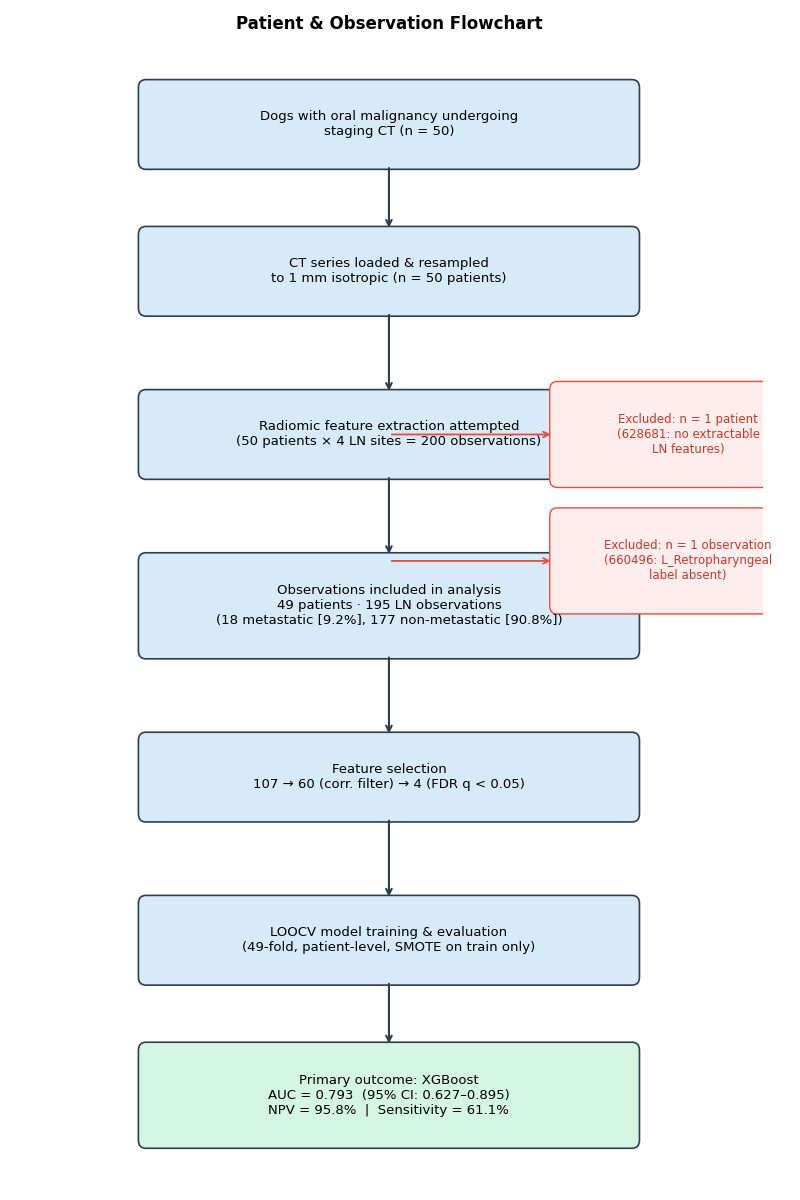

Saved: fig_consort.png


In [20]:
# ============================================================
# BLOCK H1: CONSORT / Patient Flowchart
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(8, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis("off")

def draw_box(ax, x, y, w, h, text, color="#D6EAF8", fontsize=9.5):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                         boxstyle="round,pad=0.1",
                         facecolor=color, edgecolor="#2C3E50", linewidth=1.2)
    ax.add_patch(box)
    ax.text(x, y, text, ha="center", va="center",
            fontsize=fontsize, wrap=True,
            multialignment="center", fontweight="normal")

def draw_arrow(ax, x, y1, y2):
    ax.annotate("", xy=(x, y2 + 0.05),
                xytext=(x, y1 - 0.05),
                arrowprops=dict(arrowstyle="->", color="#2C3E50", lw=1.5))

def draw_exclusion(ax, x_main, y, text):
    ax.annotate("", xy=(x_main + 2.2, y),
                xytext=(x_main, y),
                arrowprops=dict(arrowstyle="->", color="#E74C3C", lw=1.3))
    box = FancyBboxPatch((x_main + 2.25, y - 0.55), 3.5, 1.1,
                         boxstyle="round,pad=0.1",
                         facecolor="#FDEDEC", edgecolor="#E74C3C", linewidth=1)
    ax.add_patch(box)
    ax.text(x_main + 4.0, y, text, ha="center", va="center",
            fontsize=8.5, color="#C0392B", multialignment="center")

# Boxes
draw_box(ax, 5, 13.0, 6.5, 0.9,
         "Dogs with oral malignancy undergoing\nstaging CT (n = 50)")

draw_box(ax, 5, 11.2, 6.5, 0.9,
         "CT series loaded & resampled\nto 1 mm isotropic (n = 50 patients)")

draw_box(ax, 5,  9.2, 6.5, 0.9,
         "Radiomic feature extraction attempted\n(50 patients × 4 LN sites = 200 observations)")

draw_box(ax, 5,  7.1, 6.5, 1.1,
         "Observations included in analysis\n"
         "49 patients · 195 LN observations\n"
         "(18 metastatic [9.2%], 177 non-metastatic [90.8%])")

draw_box(ax, 5,  5.0, 6.5, 0.9,
         "Feature selection\n"
         "107 → 60 (corr. filter) → 4 (FDR q < 0.05)")

draw_box(ax, 5,  3.0, 6.5, 0.9,
         "LOOCV model training & evaluation\n"
         "(49-fold, patient-level, SMOTE on train only)")

draw_box(ax, 5,  1.1, 6.5, 1.1,
         "Primary outcome: XGBoost\n"
         "AUC = 0.793  (95% CI: 0.627–0.895)\n"
         "NPV = 95.8%  |  Sensitivity = 61.1%",
         color="#D5F5E3")

# Arrows
for y1, y2 in [(12.55, 11.65), (10.75, 9.65),
               (8.75,  7.65),  (6.55,  5.45),
               (4.55,  3.45),  (2.55,  1.65)]:
    draw_arrow(ax, 5, y1, y2)

# Exclusion boxes
draw_exclusion(ax, 5, 9.2,
               "Excluded: n = 1 patient\n(628681: no extractable\nLN features)")
draw_exclusion(ax, 5, 7.65,
               "Excluded: n = 1 observation\n(660496: L_Retropharyngeal\nlabel absent)")

ax.set_title("Patient & Observation Flowchart", fontsize=12,
             fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("fig_consort.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_consort.png")


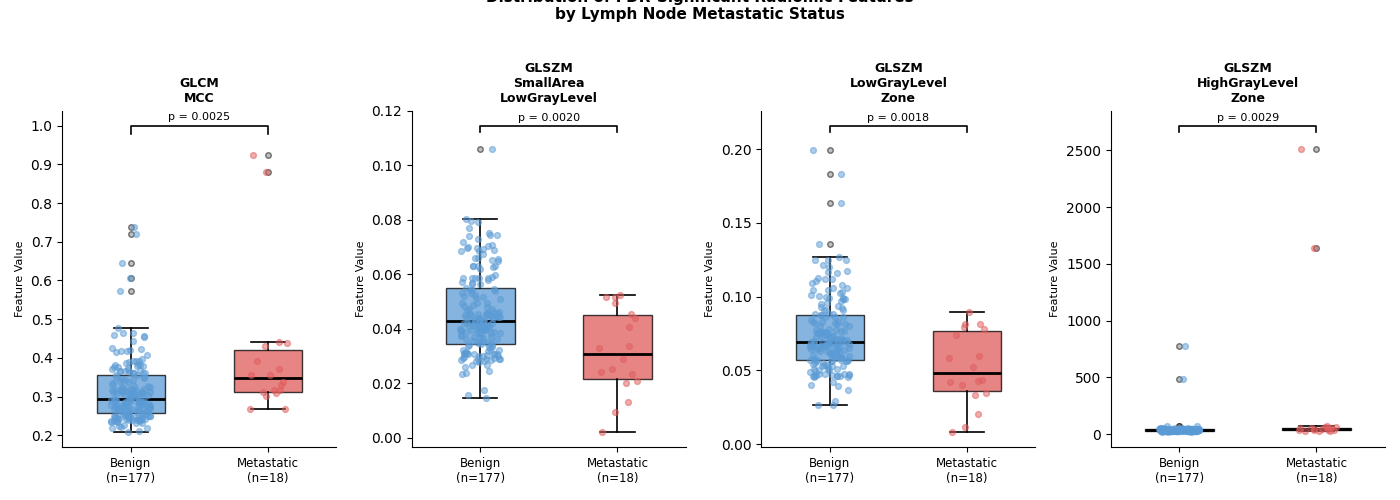

Saved: fig_boxplots.png


In [21]:
# ============================================================
# BLOCK H2: Box Plots — 4 Selected Features
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

if "features_df" not in globals():
    features_df = pd.read_csv("radiomics_features.csv")

SELECTED = [
    "original_glcm_MCC",
    "original_glszm_SmallAreaLowGrayLevelEmphasis",
    "original_glszm_LowGrayLevelZoneEmphasis",
    "original_glszm_HighGrayLevelZoneEmphasis",
]

SHORT_NAMES = {
    "original_glcm_MCC":                              "GLCM\nMCC",
    "original_glszm_SmallAreaLowGrayLevelEmphasis":   "GLSZM\nSmallArea\nLowGrayLevel",
    "original_glszm_LowGrayLevelZoneEmphasis":        "GLSZM\nLowGrayLevel\nZone",
    "original_glszm_HighGrayLevelZoneEmphasis":       "GLSZM\nHighGrayLevel\nZone",
}

COLORS = {"Benign": "#5B9BD5", "Metastatic": "#E05C5C"}

fig, axes = plt.subplots(1, 4, figsize=(14, 5))

for ax, feat in zip(axes, SELECTED):
    benign = features_df.loc[features_df["metastatic"] == 0, feat].dropna()
    meta   = features_df.loc[features_df["metastatic"] == 1, feat].dropna()

    # Mann-Whitney U
    _, p = stats.mannwhitneyu(meta, benign, alternative="two-sided")
    p_str = f"p = {p:.4f}" if p >= 0.0001 else "p < 0.0001"

    data   = [benign.values, meta.values]
    labels = ["Benign\n(n=177)", "Metastatic\n(n=18)"]
    colors = [COLORS["Benign"], COLORS["Metastatic"]]

    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker="o", markersize=4,
                                   markerfacecolor="grey", alpha=0.5))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    # Jitter overlay
    for i, (d, c) in enumerate(zip(data, colors), 1):
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(d))
        ax.scatter(np.full(len(d), i) + jitter, d,
                   color=c, alpha=0.5, s=18, zorder=3)

    # Significance bracket
    y_max = max(max(benign), max(meta)) * 1.08
    ax.plot([1, 1, 2, 2], [y_max*0.98, y_max, y_max, y_max*0.98],
            lw=1.2, color="black")
    ax.text(1.5, y_max * 1.01, p_str, ha="center", va="bottom", fontsize=8)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(labels, fontsize=8.5)
    ax.set_title(SHORT_NAMES[feat], fontsize=9, fontweight="bold")
    ax.set_ylabel("Feature Value", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Distribution of FDR-Significant Radiomic Features\n"
             "by Lymph Node Metastatic Status",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_boxplots.png")


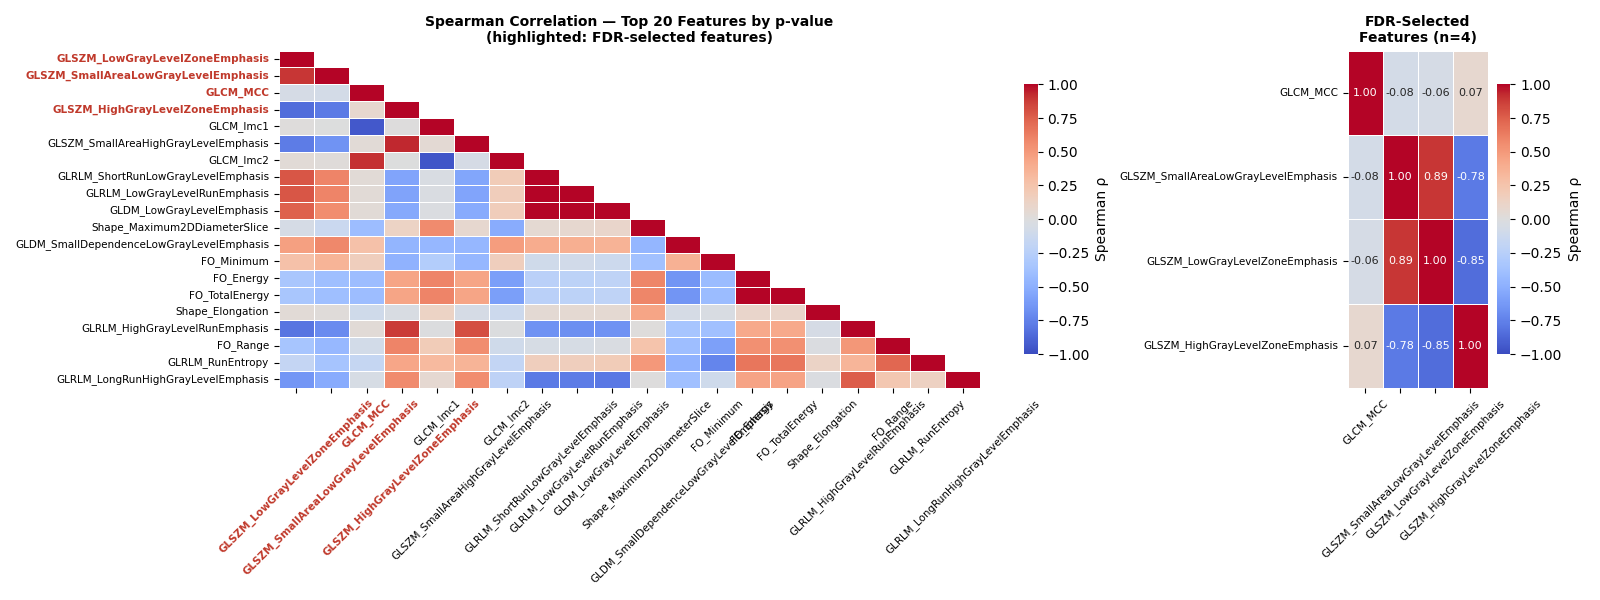

Saved: fig_correlation.png


In [22]:
# ============================================================
# BLOCK H3: Feature Correlation Heatmap (before & after)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

if "features_df" not in globals():
    features_df = pd.read_csv("radiomics_features.csv")

ID_COLS   = ["patient_id", "ln_site", "ln_label"]
LABEL_COL = "metastatic"
feat_cols = [c for c in features_df.columns if c not in ID_COLS + [LABEL_COL]]
X_all = features_df[feat_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

# Keep top 20 features by Mann-Whitney p-value for readability
y = features_df[LABEL_COL].astype(int)
pvals = {c: stats.mannwhitneyu(
             X_all.loc[y==1, c], X_all.loc[y==0, c],
             alternative="two-sided")[1]
         for c in feat_cols}
top20 = sorted(pvals, key=pvals.get)[:20]

# Short labels
def shorten(name):
    return (name.replace("original_","")
                .replace("firstorder_","FO_")
                .replace("glcm_","GLCM_")
                .replace("glszm_","GLSZM_")
                .replace("glrlm_","GLRLM_")
                .replace("gldm_","GLDM_")
                .replace("ngtdm_","NGTDM_")
                .replace("shape_","Shape_"))

short20   = [shorten(f) for f in top20]
short4    = [shorten(f) for f in SELECTED]

SELECTED = [
    "original_glcm_MCC",
    "original_glszm_SmallAreaLowGrayLevelEmphasis",
    "original_glszm_LowGrayLevelZoneEmphasis",
    "original_glszm_HighGrayLevelZoneEmphasis",
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         gridspec_kw={"width_ratios": [5, 1]})

# Left: Top-20 heatmap with selected features highlighted
corr20 = X_all[top20].corr(method="spearman")
corr20.index   = short20
corr20.columns = short20

mask = np.triu(np.ones_like(corr20, dtype=bool), k=1)
sns.heatmap(corr20, ax=axes[0], mask=mask,
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Spearman ρ", "shrink": 0.8})
axes[0].set_title("Spearman Correlation — Top 20 Features by p-value\n"
                  "(highlighted: FDR-selected features)",
                  fontsize=10, fontweight="bold")

# Highlight selected features in tick labels
for tick in axes[0].get_xticklabels():
    if tick.get_text() in short4:
        tick.set_color("#C0392B")
        tick.set_fontweight("bold")
for tick in axes[0].get_yticklabels():
    if tick.get_text() in short4:
        tick.set_color("#C0392B")
        tick.set_fontweight("bold")
axes[0].tick_params(axis="x", rotation=45, labelsize=7.5)
axes[0].tick_params(axis="y", labelsize=7.5)

# Right: 4-feature heatmap
corr4 = X_all[SELECTED].corr(method="spearman")
corr4.index   = short4
corr4.columns = short4

sns.heatmap(corr4, ax=axes[1],
            cmap="coolwarm", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", linewidths=0.5,
            cbar_kws={"label": "Spearman ρ", "shrink": 0.8},
            annot_kws={"size": 8})
axes[1].set_title("FDR-Selected\nFeatures (n=4)",
                  fontsize=10, fontweight="bold")
axes[1].tick_params(axis="x", rotation=45, labelsize=7.5)
axes[1].tick_params(axis="y", labelsize=7.5)

plt.tight_layout()
plt.savefig("fig_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_correlation.png")


In [23]:
pip install NumPy 2.2

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement 2.2 (from versions: none)
ERROR: No matching distribution found for 2.2


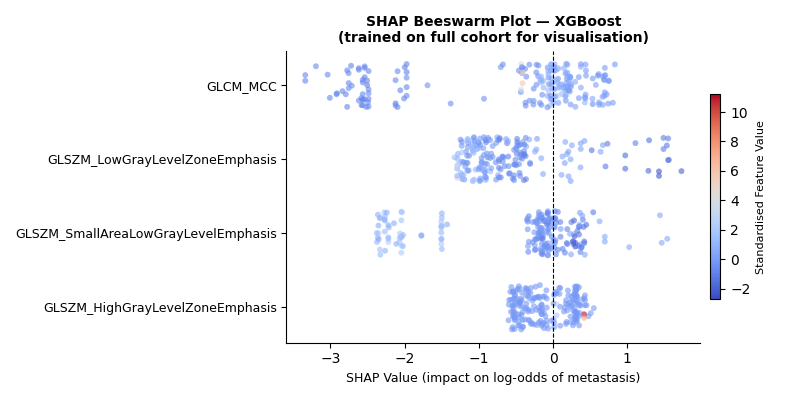

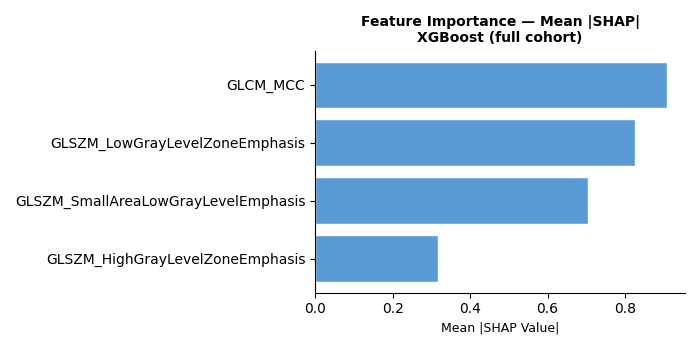

Saved: fig_shap.png  |  fig_shap_bar.png


In [24]:
# ============================================================
# BLOCK H4: SHAP Summary Plot (XGBoost native — no shap package)
# ============================================================

import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

if "ml_df" not in globals():
    ml_df = pd.read_csv("ml_ready_features.csv")

ID_COLS   = ["patient_id", "ln_site", "ln_label"]
LABEL_COL = "metastatic"
feat_cols = [c for c in ml_df.columns if c not in ID_COLS + [LABEL_COL]]

short_names = [f.replace("original_","")
                .replace("glszm_","GLSZM_")
                .replace("glcm_","GLCM_") for f in feat_cols]

X_all = ml_df[feat_cols].values
y_all = ml_df[LABEL_COL].values

# Train on full dataset (visualisation only — performance estimated by LOOCV)
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_all)
smote  = SMOTE(random_state=42, k_neighbors=4)
X_bal, y_bal = smote.fit_resample(X_sc, y_all)

xgb_full = xgb.XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    device="cuda", eval_metric="logloss",
    scale_pos_weight=(y_bal==0).sum()/(y_bal==1).sum(),
    random_state=42, verbosity=0)
xgb_full.fit(X_bal, y_bal)

# ── Extract SHAP values via XGBoost native pred_contribs ───
dmatrix     = xgb.DMatrix(X_sc, feature_names=short_names)
shap_raw    = xgb_full.get_booster().predict(dmatrix, pred_contribs=True)
shap_vals   = shap_raw[:, :-1]   # drop bias column (last)

mean_abs_shap = np.abs(shap_vals).mean(axis=0)
order = np.argsort(mean_abs_shap)   # ascending for horizontal bar

# ── Plot 1: Beeswarm-style dot plot ────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

norm = plt.Normalize(X_sc.min(), X_sc.max())
cmap = cm.get_cmap("coolwarm")

for i, feat_idx in enumerate(order):
    sv   = shap_vals[:, feat_idx]
    fv   = X_sc[:, feat_idx]
    # Jitter on y-axis for readability
    jitter = np.random.default_rng(feat_idx).uniform(-0.3, 0.3, size=len(sv))
    colors = cmap(norm(fv))
    ax.scatter(sv, np.full(len(sv), i) + jitter,
               c=colors, alpha=0.6, s=18, linewidths=0)

ax.set_yticks(range(len(feat_cols)))
ax.set_yticklabels([short_names[i] for i in order], fontsize=9)
ax.axvline(0, color="black", lw=0.8, linestyle="--")
ax.set_xlabel("SHAP Value (impact on log-odds of metastasis)", fontsize=9)
ax.set_title("SHAP Beeswarm Plot — XGBoost\n"
             "(trained on full cohort for visualisation)",
             fontsize=10, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02, shrink=0.7)
cbar.set_label("Standardised Feature Value", fontsize=8)

plt.tight_layout()
plt.savefig("fig_shap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Mean |SHAP| bar chart ──────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh([short_names[i] for i in order], mean_abs_shap[order],
        color="#5B9BD5", edgecolor="white")
ax.set_xlabel("Mean |SHAP Value|", fontsize=9)
ax.set_title("Feature Importance — Mean |SHAP|\nXGBoost (full cohort)",
             fontsize=10, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: fig_shap.png  |  fig_shap_bar.png")


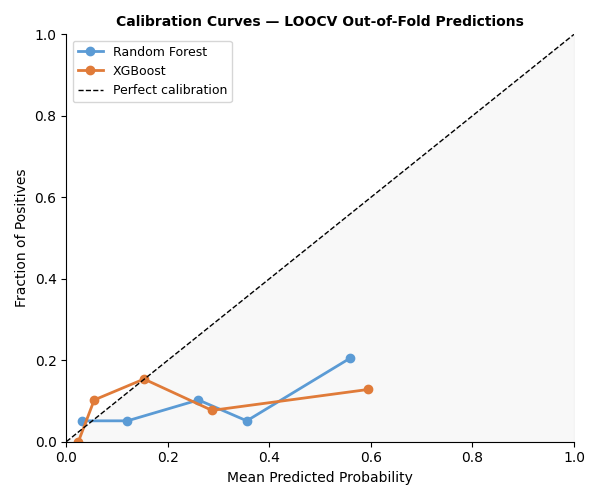

Saved: fig_calibration.png


In [25]:
# ============================================================
# BLOCK H5: Calibration Curve (XGBoost LOOCV predictions)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

if "oof" not in globals():
    raise RuntimeError("Run Block F (LOOCV) first.")

fig, ax = plt.subplots(figsize=(6, 5))

colors = {"Random Forest": "#5B9BD5", "XGBoost": "#E07B39"}

for name, color in colors.items():
    y_true = np.array(oof[name]["y_true"])
    y_prob = np.array(oof[name]["y_prob"])

    # n_bins=5 given small positive class size
    frac_pos, mean_pred = calibration_curve(y_true, y_prob,
                                            n_bins=5, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", color=color,
            lw=2, markersize=6, label=name)

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
ax.fill_between([0, 1], [0, 1], alpha=0.05, color="grey")

ax.set_xlabel("Mean Predicted Probability", fontsize=10)
ax.set_ylabel("Fraction of Positives", fontsize=10)
ax.set_title("Calibration Curves — LOOCV Out-of-Fold Predictions",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig_calibration.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_calibration.png")



LN Site                    N (meta/total)    RF AUC   XGB AUC
--------------------------------------------------------------
L_Mandibular                         6/49     0.752     0.694
R_Mandibular                         9/49     0.769     0.750
L_Retropharyngeal                    1/48      N/A*      N/A*
R_Retropharyngeal                    2/49     0.170     0.319
* Fewer than 2 positive cases; AUC undefined


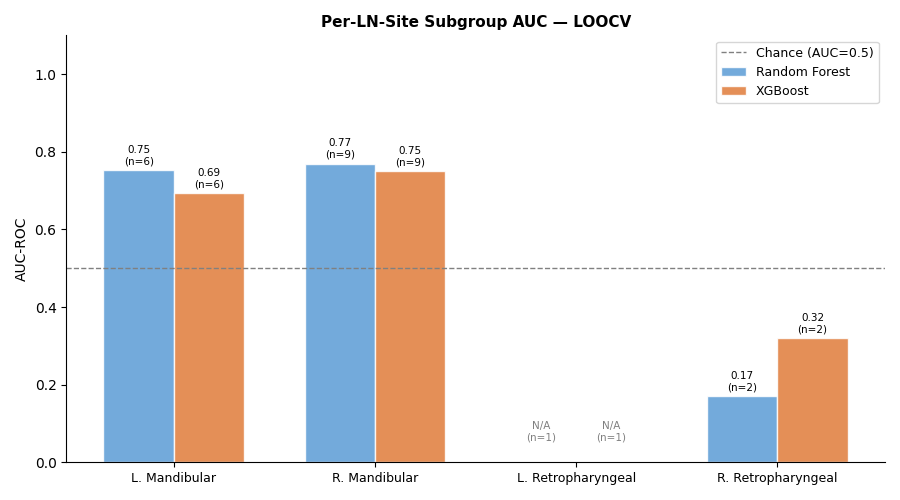

Saved: fig_subgroup.png


In [26]:
# ============================================================
# BLOCK H6: Per-LN-Site Subgroup Analysis
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

if "oof" not in globals():
    raise RuntimeError("Run Block F (LOOCV) first.")
if "ml_df" not in globals():
    ml_df = pd.read_csv("ml_ready_features.csv")

# Reconstruct OOF DataFrame preserving the patient order from Block F
unique_pids = ml_df["patient_id"].unique()
ml_ordered = pd.concat(
    [ml_df[ml_df["patient_id"] == pid] for pid in unique_pids]
).reset_index(drop=True)

results_by_site = {}

for model_name in ["Random Forest", "XGBoost"]:
    y_true = np.array(oof[model_name]["y_true"])
    y_prob = np.array(oof[model_name]["y_prob"])
    sites  = ml_ordered["ln_site"].values

    site_results = {}
    for site in ["L_Mandibular", "R_Mandibular",
                 "L_Retropharyngeal", "R_Retropharyngeal"]:
        mask = sites == site
        yt = y_true[mask]
        yp = y_prob[mask]
        n_pos = yt.sum()
        n_tot = len(yt)
        if n_pos < 2:
            auc = np.nan
        else:
            auc = roc_auc_score(yt, yp)
        site_results[site] = {
            "auc": auc, "n_pos": n_pos, "n_tot": n_tot
        }
    results_by_site[model_name] = site_results

# ── Table ───────────────────────────────────────────────────
print(f"\n{'LN Site':<25} {'N (meta/total)':>15}  "
      f"{'RF AUC':>8}  {'XGB AUC':>8}")
print("-" * 62)
for site in ["L_Mandibular", "R_Mandibular",
             "L_Retropharyngeal", "R_Retropharyngeal"]:
    rf  = results_by_site["Random Forest"][site]
    xgb = results_by_site["XGBoost"][site]
    auc_rf  = f"{rf['auc']:.3f}"  if not np.isnan(rf['auc'])  else "N/A*"
    auc_xgb = f"{xgb['auc']:.3f}" if not np.isnan(xgb['auc']) else "N/A*"
    label = f"{rf['n_pos']}/{rf['n_tot']}"
    print(f"{site:<25} {label:>15}  {auc_rf:>8}  {auc_xgb:>8}")
print("* Fewer than 2 positive cases; AUC undefined")

# ── Bar chart ───────────────────────────────────────────────
sites_short = ["L_Mandibular", "R_Mandibular",
               "L_Retropharyngeal", "R_Retropharyngeal"]
labels_short = ["L. Mandibular", "R. Mandibular",
                "L. Retropharyngeal", "R. Retropharyngeal"]
x = np.arange(len(sites_short))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
for offset, (mname, color) in enumerate(
        zip(["Random Forest", "XGBoost"], ["#5B9BD5", "#E07B39"])):
    aucs = [results_by_site[mname][s]["auc"] for s in sites_short]
    ns   = [results_by_site[mname][s]["n_pos"] for s in sites_short]
    bars = ax.bar(x + offset*w, aucs, w, label=mname,
                  color=color, alpha=0.85, edgecolor="white")
    for bar, auc_val, n in zip(bars, aucs, ns):
        if not np.isnan(auc_val):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f"{auc_val:.2f}\n(n={n})",
                    ha="center", va="bottom", fontsize=7.5)
        else:
            ax.text(bar.get_x() + bar.get_width()/2,
                    0.05, f"N/A\n(n={n})",
                    ha="center", va="bottom", fontsize=7.5, color="grey")

ax.axhline(0.5, color="grey", linestyle="--", lw=1, label="Chance (AUC=0.5)")
ax.set_xticks(x + w/2)
ax.set_xticklabels(labels_short, fontsize=9)
ax.set_ylabel("AUC-ROC", fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title("Per-LN-Site Subgroup AUC — LOOCV",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig_subgroup.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_subgroup.png")
